## Comprensión y Análisis Exploratorio de Datos (EDA)


Este notebook tiene como objetivo comprender la estructura, calidad y características del dataset utilizado en el Proyecto Integrador del Módulo 5.

El análisis se realizará de manera progresiva, comenzando por una exploración inicial de los datos y continuando posteriormente con el tratamiento de calidad, análisis univariado, bivariado y multivariado.

En esta primera etapa se busca identificar la estructura del dataset, los tipos de datos detectados, la presencia de valores faltantes, posibles duplicados y la cardinalidad de las variables, sin realizar todavía transformaciones sobre los datos originales.

### Exploración Inicial

In [1]:
from pathlib import Path
import pandas as pd

In [2]:
ruta_datos = Path.cwd().parent / "Base_de_datos.csv"

if not ruta_datos.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {ruta_datos}")

df = pd.read_csv(ruta_datos, sep=";")

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado correctamente.
Filas: 10763
Columnas: 23


In [3]:
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,21/12/2024 11:31,3692160,10,42,Independiente,8000000,2500000,341296,"88,768094",...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,22/4/2025 09:47,840000,6,60,Empleado,3000000,2000000,124876,"95,227787",...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,8/1/2026 12:22,5974028,10,36,Independiente,4036000,829000,529554,"47,613894",...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,4/8/2025 12:04,1671240,6,48,Empleado,1524547,498000,252420,"95,227787",...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,26/4/2025 11:24,2781636,11,44,Empleado,5000000,4000000,217037,"95,227787",...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [4]:
print(f"Cantidad de registros: {df.shape[0]}")
print(f"Cantidad de variables: {df.shape[1]}")

print("\nVariables del dataset:")
for i, columna in enumerate(df.columns, start=1):
    print(f"{i}. {columna}")

Cantidad de registros: 10763
Cantidad de variables: 23

Variables del dataset:
1. tipo_credito
2. fecha_prestamo
3. capital_prestado
4. plazo_meses
5. edad_cliente
6. tipo_laboral
7. salario_cliente
8. total_otros_prestamos
9. cuota_pactada
10. puntaje
11. puntaje_datacredito
12. cant_creditosvigentes
13. huella_consulta
14. saldo_mora
15. saldo_total
16. saldo_principal
17. saldo_mora_codeudor
18. creditos_sectorFinanciero
19. creditos_sectorCooperativo
20. creditos_sectorReal
21. promedio_ingresos_datacredito
22. tendencia_ingresos
23. Pago_atiempo


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  int64  
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  str    
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null  int64  
 1

In [6]:
cantidad_duplicados = df.duplicated().sum()

print(f"Cantidad de filas duplicadas: {cantidad_duplicados}")
print(f"Porcentaje de filas duplicadas: {cantidad_duplicados / len(df) * 100:.2f}%")

Cantidad de filas duplicadas: 0
Porcentaje de filas duplicadas: 0.00%


In [7]:
# Resumen de calidad por Variable

resumen_columnas = pd.DataFrame({
    "tipo_detectado": df.dtypes.astype(str),
    "no_nulos": df.notna().sum(),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(dropna=True)
})

resumen_columnas = resumen_columnas.sort_values(
    by="porcentaje_nulos",
    ascending=False
)

resumen_columnas

,tipo_detectado,no_nulos,nulos,porcentaje_nulos,valores_unicos
tendencia_ingresos,str,7831,2932,27.24,46
promedio_ingresos_datacredito,float64,7833,2930,27.22,5309
saldo_mora_codeudor,float64,10173,590,5.48,4
saldo_principal,float64,10358,405,3.76,8647
saldo_mora,float64,10607,156,1.45,55
saldo_total,float64,10607,156,1.45,8858
puntaje_datacredito,float64,10757,6,0.06,315
salario_cliente,int64,10763,0,0.00,1385
tipo_laboral,str,10763,0,0.00,2
edad_cliente,int64,10763,0,0.00,54


#### Caracterización preliminar de variables

A partir de los tipos detectados por Pandas, la cardinalidad y el significado sugerido por los nombres de las variables, se realiza una primera caracterización conceptual.

Esta clasificación es preliminar debido a que no se dispone de un diccionario formal de variables. Por este motivo, las variables con baja cardinalidad, formatos inconsistentes o significado ambiguo serán inspeccionadas antes de realizar transformaciones.

In [8]:
columnas_a_revisar = [
    "tipo_credito",
    "tipo_laboral",
    "puntaje",
    "saldo_mora_codeudor",
    "tendencia_ingresos",
    "Pago_atiempo"
]

for columna in columnas_a_revisar:
    print(f"\n{'=' * 60}")
    print(f"Variable: {columna}")
    print(f"Tipo detectado: {df[columna].dtype}")
    print(f"Valores únicos: {df[columna].nunique(dropna=True)}")
    print("\nValores más frecuentes:")
    print(df[columna].value_counts(dropna=False).head(15))


Variable: tipo_credito
Tipo detectado: int64
Valores únicos: 6

Valores más frecuentes:
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

Variable: tipo_laboral
Tipo detectado: str
Valores únicos: 2

Valores más frecuentes:
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

Variable: puntaje
Tipo detectado: str
Valores únicos: 248

Valores más frecuentes:
puntaje
95,227787    9407
89,979287      99
89,2295        82
91,99794       73
47,613894      59
84,730786      59
91,728786      56
92,228643      51
90,562453      46
91,410695      45
88,229786      44
86,830187      34
81,231786      29
91,028987      25
85,897119      21
Name: count, dtype: int64

Variable: saldo_mora_codeudor
Tipo detectado: float64
Valores únicos: 4

Valores más frecuentes:
saldo_mora_codeudor
0.0       10170
NaN         590
2145.0        1
30.0          1
470.0         1
Name: count, dtype: int64

Variable: tendencia_ing

In [9]:
# Check Tendencia Ingresos

valores_tendencia = df["tendencia_ingresos"].dropna().unique()

print("Valores únicos de tendencia_ingresos:")
print(valores_tendencia)

Valores únicos de tendencia_ingresos:
<ArrowStringArray>
[    'Estable',   'Creciente', 'Decreciente',        '8315',           '0',
      '158042',        '3978',        '9147',      '168750',      '-28589',
     '1000000',     '-566272',       '24702',       '31837',      '122727',
      '417087',        '9090',      '173031',      '-70715',     '-435177',
     '-702927',       '-4105',       '54683',       '22832',      '209090',
        '5697',       '10808',        '-288',     '-164315',     '2029000',
       '17181',       '15245',       '82657',       '52862',     '1817052',
       '75761',      '146918',     '1123000',       '15090',     '4250635',
       '22363',     '-101368',       '86286',       '65988',       '77975',
     '-224714']
Length: 46, dtype: str


In [10]:
# Check Variable Objetivo

distribucion_objetivo = (
    df["Pago_atiempo"]
    .value_counts(dropna=False)
    .sort_index()
)

porcentaje_objetivo = (
    df["Pago_atiempo"]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
    .mul(100)
    .round(2)
)

resumen_objetivo = pd.DataFrame({
    "cantidad": distribucion_objetivo,
    "porcentaje": porcentaje_objetivo
})

resumen_objetivo

,cantidad,porcentaje
Pago_atiempo,,
0,511,4.75
1,10252,95.25


In [11]:
print("Tipo:", df["puntaje"].dtype)
print("Valores únicos:", df["puntaje"].nunique(dropna=True))

print("\nPrimeros valores:")
print(df["puntaje"].head(15))

print("\nValores más frecuentes:")
print(df["puntaje"].value_counts(dropna=False).head(15))

Tipo: str
Valores únicos: 248

Primeros valores:
0     88,768094
1     95,227787
2     47,613894
3     95,227787
4     95,227787
5     95,227787
6     95,227787
7     95,227787
8     95,227787
9     95,227787
10    95,227787
11    95,227787
12    95,227787
13    95,227787
14    95,227787
Name: puntaje, dtype: str

Valores más frecuentes:
puntaje
95,227787    9407
89,979287      99
89,2295        82
91,99794       73
47,613894      59
84,730786      59
91,728786      56
92,228643      51
90,562453      46
91,410695      45
88,229786      44
86,830187      34
81,231786      29
91,028987      25
85,897119      21
Name: count, dtype: int64


In [12]:
puntaje_numerico_prueba = pd.to_numeric(
    df["puntaje"].str.replace(",", ".", regex=False),
    errors="coerce"
)

print("Valores que podrían convertirse a número:",
      puntaje_numerico_prueba.notna().sum())

print("Valores que no pudieron convertirse:",
      puntaje_numerico_prueba.isna().sum())

Valores que podrían convertirse a número: 10763
Valores que no pudieron convertirse: 0


In [13]:
print("Tipo:", df["saldo_mora_codeudor"].dtype)
print("Valores únicos:", df["saldo_mora_codeudor"].nunique(dropna=True))

print("\nDistribución completa:")
print(
    df["saldo_mora_codeudor"]
    .value_counts(dropna=False)
    .sort_index()
)

Tipo: float64
Valores únicos: 4

Distribución completa:
saldo_mora_codeudor
0.0       10170
30.0          1
470.0         1
2145.0        1
NaN         590
Name: count, dtype: int64


In [14]:
categorias_tendencia = ["Estable", "Creciente", "Decreciente"]

es_categoria = df["tendencia_ingresos"].isin(categorias_tendencia)

tendencia_numerica_prueba = pd.to_numeric(
    df["tendencia_ingresos"],
    errors="coerce"
)

print("Categorías esperadas:", es_categoria.sum())
print("Valores numéricos almacenados como texto:",
      tendencia_numerica_prueba.notna().sum())
print("Valores nulos:", df["tendencia_ingresos"].isna().sum())

Categorías esperadas: 7773
Valores numéricos almacenados como texto: 58
Valores nulos: 2932


#### Conclusiones de la exploración inicial

El dataset contiene **10.763 registros y 23 variables**, sin filas completamente duplicadas.

La revisión inicial permitió identificar valores faltantes concentrados principalmente en `tendencia_ingresos` (27,24 %) y `promedio_ingresos_datacredito` (27,22 %), además de proporciones menores de ausencia en variables relacionadas con saldos y puntajes.

También se identificaron inconsistencias en los tipos de datos. La variable `fecha_prestamo` se encuentra almacenada como texto y deberá convertirse a un formato temporal. Por su parte, `puntaje` está almacenada como texto debido al uso de coma como separador decimal; se comprobó que sus 10.763 registros pueden convertirse correctamente a formato numérico.

La variable `tendencia_ingresos` requiere especial atención. De los 10.763 registros, 7.773 contienen las categorías esperadas (`Estable`, `Creciente` o `Decreciente`), 58 contienen valores numéricos almacenados como texto y 2.932 corresponden a valores faltantes. Al no contar con un diccionario de variables, estos casos se deberán analizar antes de definir una transformación.

También se detectaron variables con distribuciones particulares. `saldo_mora_codeudor` presenta 10.170 registros con valor cero, únicamente tres registros con valores positivos y 590 valores faltantes. Asimismo, `tipo_credito` presenta un valor poco frecuente (`68`) que aparece en un único registro y que deberá ser revisado sin asumir inicialmente que se trata de un error.

Finalmente, `Pago_atiempo` presenta dos valores (0 y 1) y, por el contexto del problema, se considera la variable objetivo. Su distribución se encuentra fuertemente desbalanceada: el 95,25 % de los registros pertenece a la clase 1 y el 4,75 % a la clase 0.

En esta etapa no se realizaron modificaciones sobre los datos. Los hallazgos obtenidos serán utilizados para definir de manera justificada las reglas de limpieza, tipificación y tratamiento de valores faltantes.

### Calidad y tipificación de los datos

A partir de los hallazgos obtenidos durante la exploración inicial, se revisará la calidad de los datos y se aplicarán únicamente aquellas transformaciones que puedan justificarse a partir de la evidencia disponible.

Para preservar los datos cargados originalmente, las transformaciones se realizarán sobre una copia del DataFrame.

In [15]:
df_limpio = df.copy()

print(f"Dimensiones del DataFrame original: {df.shape}")
print(f"Dimensiones de la copia de trabajo: {df_limpio.shape}")

Dimensiones del DataFrame original: (10763, 23)
Dimensiones de la copia de trabajo: (10763, 23)


In [16]:
# Check si existen nulos representados como texto

columnas_texto = df_limpio.select_dtypes(
    include=["object", "string"]
).columns.tolist()

marcadores_nulos = [
    "",
    "na",
    "n/a",
    "null",
    "none",
    "nan",
    "s/d",
    "sin dato"
]

print("Columnas de texto revisadas:")
print(columnas_texto)

print("\nMarcadores textuales de nulos encontrados:")

encontrados = False

for columna in columnas_texto:
    serie_normalizada = (
        df_limpio[columna]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    mascara = serie_normalizada.isin(marcadores_nulos)
    cantidad = mascara.sum()

    if cantidad > 0:
        encontrados = True
        print(f"- {columna}: {cantidad}")

if not encontrados:
    print("No se detectaron marcadores textuales adicionales.")

Columnas de texto revisadas:
['fecha_prestamo', 'tipo_laboral', 'puntaje', 'tendencia_ingresos']

Marcadores textuales de nulos encontrados:
No se detectaron marcadores textuales adicionales.


In [17]:
fecha_prueba = pd.to_datetime(
    df_limpio["fecha_prestamo"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

print("Registros originales no nulos:",
      df_limpio["fecha_prestamo"].notna().sum())

print("Fechas convertidas correctamente:",
      fecha_prueba.notna().sum())

print("Fechas que no pudieron convertirse:",
      fecha_prueba.isna().sum())

print("\nFecha mínima:", fecha_prueba.min())
print("Fecha máxima:", fecha_prueba.max())

Registros originales no nulos: 10763
Fechas convertidas correctamente: 10763
Fechas que no pudieron convertirse: 0

Fecha mínima: 2024-11-26 09:17:00
Fecha máxima: 2026-04-26 18:43:00


In [18]:
columnas_constantes = [
    columna
    for columna in df_limpio.columns
    if df_limpio[columna].nunique(dropna=False) <= 1
]

print("Columnas constantes:")
print(columnas_constantes)

Columnas constantes:
[]


In [19]:
columnas_totalmente_nulas = [
    columna
    for columna in df_limpio.columns
    if df_limpio[columna].isna().all()
]

print("Columnas completamente nulas:")
print(columnas_totalmente_nulas)

Columnas completamente nulas:
[]


In [20]:
columnas_duplicadas = (
    df_limpio.T
    .duplicated()
)

nombres_columnas_duplicadas = (
    df_limpio.columns[columnas_duplicadas]
    .tolist()
)

print("Columnas duplicadas:")
print(nombres_columnas_duplicadas)

Columnas duplicadas:
[]


In [21]:
# Como no tengo columnas identificadas como ID, chequeo de valores únicos
ratio_unicidad = (
    df_limpio.nunique(dropna=False)
    .div(len(df_limpio))
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

ratio_unicidad.to_frame("porcentaje_valores_unicos").head(10)

,porcentaje_valores_unicos
fecha_prestamo,97.04
cuota_pactada,91.39
saldo_total,82.31
saldo_principal,80.35
capital_prestado,67.88
promedio_ingresos_datacredito,49.34
total_otros_prestamos,14.29
salario_cliente,12.87
puntaje_datacredito,2.94
puntaje,2.30


No se eliminaron variables en esta etapa porque no se identificaron columnas claramente irrelevantes y no se dispone de un diccionario de datos que permita justificar la exclusión semántica de alguna característica.

#### Decisiones de calidad y tipificación

A partir de las verificaciones realizadas se definieron las siguientes decisiones:

- No se identificaron columnas constantes, completamente nulas o duplicadas.
- No se eliminarán variables en esta etapa, ya que no se detectaron identificadores explícitos ni columnas cuya irrelevancia pueda justificarse con la información disponible.
- `fecha_prestamo` será convertida a formato temporal, ya que todos sus registros pudieron interpretarse correctamente como fechas.
- `puntaje` será convertido a formato numérico reemplazando la coma decimal por punto. La conversión fue previamente validada sobre los 10.763 registros sin pérdidas.
- `tipo_credito` será tratada como variable categórica nominal, conservando todos sus valores actuales, incluido el valor poco frecuente `68`, debido a que no existe información suficiente para considerarlo un error.
- `tipo_laboral` será tratada como variable categórica nominal.
- `tendencia_ingresos` será tratada como variable categórica. Los 58 valores numéricos almacenados como texto no corresponden a las categorías observadas (`Estable`, `Creciente`, `Decreciente`) y, ante la ausencia de un diccionario de datos, serán considerados valores inválidos/faltantes en la copia de trabajo.
- Los valores faltantes existentes no serán imputados en esta etapa, ya que primero se analizarán sus distribuciones y relaciones con otras variables.
- `Pago_atiempo` se conservará codificada como 0/1, aunque conceptualmente se reconoce como una variable categórica binaria y posible variable objetivo.

In [22]:
# Conversión fecha_prestamo

df_limpio["fecha_prestamo"] = pd.to_datetime(
    df_limpio["fecha_prestamo"],
    format="mixed",
    dayfirst=True,
    errors="raise"
)

print("Nuevo tipo de fecha_prestamo:")
print(df_limpio["fecha_prestamo"].dtype)

Nuevo tipo de fecha_prestamo:
datetime64[us]


In [23]:
# Conversión puntaje

df_limpio["puntaje"] = pd.to_numeric(
    df_limpio["puntaje"].str.replace(",", ".", regex=False),
    errors="raise"
)

print("Nuevo tipo de puntaje:")
print(df_limpio["puntaje"].dtype)

print("\nPrimeros valores:")
print(df_limpio["puntaje"].head())

Nuevo tipo de puntaje:
float64

Primeros valores:
0    88.768094
1    95.227787
2    47.613894
3    95.227787
4    95.227787
Name: puntaje, dtype: float64


In [24]:
# Conversión variables categóricas

df_limpio["tipo_credito"] = df_limpio["tipo_credito"].astype("category")
df_limpio["tipo_laboral"] = df_limpio["tipo_laboral"].astype("category")

print("Tipo de tipo_credito:", df_limpio["tipo_credito"].dtype)
print("Tipo de tipo_laboral:", df_limpio["tipo_laboral"].dtype)

Tipo de tipo_credito: category
Tipo de tipo_laboral: category


In [25]:
# Crear mascara para tendencia_ingresos

categorias_tendencia = ["Estable", "Creciente", "Decreciente"]

mascara_tendencia_invalida = (
    df_limpio["tendencia_ingresos"].notna()
    & ~df_limpio["tendencia_ingresos"].isin(categorias_tendencia)
)

print(
    "Valores no nulos fuera de las categorías esperadas:",
    mascara_tendencia_invalida.sum()
)

Valores no nulos fuera de las categorías esperadas: 58


In [26]:
# Incorporar valores fuera de las categorias como nulos
df_limpio.loc[
    mascara_tendencia_invalida,
    "tendencia_ingresos"
] = pd.NA

df_limpio["tendencia_ingresos"] = (
    df_limpio["tendencia_ingresos"]
    .astype("category")
)

print(df_limpio["tendencia_ingresos"].value_counts(dropna=False))

tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64


Los 58 casos se incorporan como inválidos dado que no se cuenta con información que haga que los considere en una de las categorías (creciente, estable, decreciente).

In [27]:
print("Dimensiones después de la tipificación:")
print(df_limpio.shape)

print("\nTipos de datos:")
print(df_limpio.dtypes)

Dimensiones después de la tipificación:
(10763, 23)

Tipos de datos:
tipo_credito                           category
fecha_prestamo                   datetime64[us]
capital_prestado                          int64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                           category
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal

In [28]:
resumen_nulos_limpio = pd.DataFrame({
    "nulos": df_limpio.isna().sum(),
    "porcentaje_nulos": (
        df_limpio.isna().mean() * 100
    ).round(2)
})

resumen_nulos_limpio = (
    resumen_nulos_limpio[
        resumen_nulos_limpio["nulos"] > 0
    ]
    .sort_values(
        "porcentaje_nulos",
        ascending=False
    )
)

resumen_nulos_limpio

,nulos,porcentaje_nulos
tendencia_ingresos,2990,27.78
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


In [29]:
# Chequeo si se modifico df original

print("Tipo de puntaje en df original:")
print(df["puntaje"].dtype)

print("\nTipo de puntaje en df_limpio:")
print(df_limpio["puntaje"].dtype)

print("\nNulos de tendencia_ingresos en df original:")
print(df["tendencia_ingresos"].isna().sum())

print("\nNulos de tendencia_ingresos en df_limpio:")
print(df_limpio["tendencia_ingresos"].isna().sum())

Tipo de puntaje en df original:
str

Tipo de puntaje en df_limpio:
float64

Nulos de tendencia_ingresos en df original:
2932

Nulos de tendencia_ingresos en df_limpio:
2990


#### Conclusiones de calidad y tipificación

El proceso de calidad y tipificación se realizó sobre una copia del DataFrame original (`df_limpio`), permitiendo preservar los datos tal como fueron cargados inicialmente.

No se detectaron columnas constantes, completamente nulas o duplicadas. Tampoco se identificaron variables cuya eliminación pudiera justificarse de manera objetiva con la información disponible, por lo que se conservaron las 23 variables originales.

La variable `fecha_prestamo` fue convertida correctamente de texto a formato temporal, sin generar valores faltantes durante la conversión. A su vez, `puntaje` fue transformada de texto a formato numérico corrigiendo el uso de la coma como separador decimal. Los 10.763 registros pudieron convertirse correctamente.

Las variables `tipo_credito` y `tipo_laboral` fueron tipificadas como categóricas debido a su naturaleza conceptual. En el caso de `tipo_credito`, se conservaron todos los códigos observados, incluido el valor poco frecuente `68`, ya que no existe información suficiente para considerarlo un error.

Para `tendencia_ingresos` se identificaron 58 registros no nulos que contenían valores numéricos almacenados como texto en lugar de las categorías observadas (`Estable`, `Creciente` y `Decreciente`). Debido a la ausencia de un diccionario de datos que permita interpretar esos valores de manera confiable, fueron representados como valores faltantes en la copia de trabajo. De esta forma, la cantidad de nulos en esta variable pasó de 2.932 a 2.990 registros.

Los valores faltantes restantes no fueron imputados en esta etapa. Su tratamiento se pospone hasta analizar las distribuciones y relaciones entre variables, evitando introducir supuestos que puedan alterar innecesariamente la información.

Finalmente, las transformaciones conservaron las dimensiones originales del dataset: **10.763 registros y 23 variables**.

#### Tratamiento de valores faltantes

Los valores faltantes fueron identificados y su representación fue uniformada, pero no se realizó imputación en esta etapa.

Esta decisión busca preservar la distribución original de los datos y evitar introducir valores artificiales antes de analizar el comportamiento individual y las relaciones entre las variables.

El tratamiento definitivo de los valores faltantes se definirá según la naturaleza de cada variable, la proporción de ausencia y su relación con la variable objetivo. No se asumirá, que un valor faltante equivale a cero cuando dicha interpretación no pueda justificarse con la información disponible.

### Análisis Univariado

El análisis univariado estudia cada variable de manera individual con el objetivo de comprender su distribución, tendencia central, dispersión, frecuencia de categorías y presencia de posibles valores extremos.

El análisis se realizará diferenciando las variables según su naturaleza conceptual: numéricas, categóricas y temporales.

Los valores identificados visualmente como extremos no serán eliminados automáticamente. Cuando se detecte una posible anomalía de calidad, se realizará una inspección específica antes de decidir cualquier tratamiento.

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
variables_numericas = [
    "capital_prestado",
    "plazo_meses",
    "edad_cliente",
    "salario_cliente",
    "total_otros_prestamos",
    "cuota_pactada",
    "puntaje",
    "puntaje_datacredito",
    "cant_creditosvigentes",
    "huella_consulta",
    "saldo_mora",
    "saldo_total",
    "saldo_principal",
    "saldo_mora_codeudor",
    "creditos_sectorFinanciero",
    "creditos_sectorCooperativo",
    "creditos_sectorReal",
    "promedio_ingresos_datacredito"
]

variables_categoricas = [
    "tipo_credito",
    "tipo_laboral",
    "tendencia_ingresos",
    "Pago_atiempo"
]

variable_temporal = "fecha_prestamo"

print(f"Variables numéricas: {len(variables_numericas)}")
print(f"Variables categóricas: {len(variables_categoricas)}")
print(f"Variable temporal: {variable_temporal}")

Variables numéricas: 18
Variables categóricas: 4
Variable temporal: fecha_prestamo


In [32]:
descripcion_numericas = (
    df_limpio[variables_numericas]
    .describe()
    .T
    .round(2)
)

descripcion_numericas

,count,mean,std,min,25%,50%,75%,max
capital_prestado,10763.0,2434315.00,1.909643e+06,360000.00,1224831.00,1921920.00,3084840.00,4.144415e+07
plazo_meses,10763.0,10.58,6.630000e+00,2.00,6.00,10.00,12.00,9.000000e+01
edad_cliente,10763.0,43.95,1.506000e+01,19.00,33.00,42.00,53.00,1.230000e+02
salario_cliente,10763.0,17216431.46,3.554767e+08,0.00,2000000.00,3000000.00,4875808.00,2.200000e+10
total_otros_prestamos,10763.0,6238869.65,1.184183e+08,0.00,500000.00,1000000.00,2000000.00,6.787675e+09
cuota_pactada,10763.0,243617.41,2.104937e+05,23944.00,121041.50,182863.00,287833.50,3.816752e+06
puntaje,10763.0,91.17,1.647000e+01,-38.01,95.23,95.23,95.23,9.523000e+01
puntaje_datacredito,10757.0,780.79,1.048800e+02,-7.00,757.00,791.00,825.00,9.990000e+02
cant_creditosvigentes,10763.0,5.73,3.980000e+00,0.00,3.00,5.00,8.00,6.200000e+01
huella_consulta,10763.0,4.23,3.060000e+00,0.00,2.00,4.00,6.00,2.900000e+01


In [33]:
estadisticas_univariadas = pd.DataFrame(index=variables_numericas)

estadisticas_univariadas["media"] = df_limpio[variables_numericas].mean()
estadisticas_univariadas["mediana"] = df_limpio[variables_numericas].median()
estadisticas_univariadas["moda"] = (
    df_limpio[variables_numericas]
    .mode(dropna=True)
    .iloc[0]
)

estadisticas_univariadas["minimo"] = df_limpio[variables_numericas].min()
estadisticas_univariadas["Q1"] = df_limpio[variables_numericas].quantile(0.25)
estadisticas_univariadas["Q3"] = df_limpio[variables_numericas].quantile(0.75)
estadisticas_univariadas["maximo"] = df_limpio[variables_numericas].max()

estadisticas_univariadas["rango"] = (
    estadisticas_univariadas["maximo"]
    - estadisticas_univariadas["minimo"]
)

estadisticas_univariadas["IQR"] = (
    estadisticas_univariadas["Q3"]
    - estadisticas_univariadas["Q1"]
)

estadisticas_univariadas["varianza"] = df_limpio[variables_numericas].var()
estadisticas_univariadas["desviacion_std"] = df_limpio[variables_numericas].std()
estadisticas_univariadas["asimetria"] = df_limpio[variables_numericas].skew()
estadisticas_univariadas["curtosis"] = df_limpio[variables_numericas].kurt()
estadisticas_univariadas["nulos"] = df_limpio[variables_numericas].isna().sum()

In [34]:
estadisticas_univariadas[
    [
        "media",
        "mediana",
        "moda",
        "minimo",
        "Q1",
        "Q3",
        "maximo"
    ]
].round(2)

,media,mediana,moda,minimo,Q1,Q3,maximo
capital_prestado,2434315.00,1921920.00,1200000.00,360000.00,1224831.00,3084840.00,4.144415e+07
plazo_meses,10.58,10.00,6.00,2.00,6.00,12.00,9.000000e+01
edad_cliente,43.95,42.00,40.00,19.00,33.00,53.00,1.230000e+02
salario_cliente,17216431.46,3000000.00,3000000.00,0.00,2000000.00,4875808.00,2.200000e+10
total_otros_prestamos,6238869.65,1000000.00,2000000.00,0.00,500000.00,2000000.00,6.787675e+09
cuota_pactada,243617.41,182863.00,205990.00,23944.00,121041.50,287833.50,3.816752e+06
puntaje,91.17,95.23,95.23,-38.01,95.23,95.23,9.523000e+01
puntaje_datacredito,780.79,791.00,0.00,-7.00,757.00,825.00,9.990000e+02
cant_creditosvigentes,5.73,5.00,4.00,0.00,3.00,8.00,6.200000e+01
huella_consulta,4.23,4.00,2.00,0.00,2.00,6.00,2.900000e+01


In [35]:
estadisticas_univariadas[
    [
        "rango",
        "IQR",
        "varianza",
        "desviacion_std",
        "asimetria",
        "curtosis",
        "nulos"
    ]
].round(2)

,rango,IQR,varianza,desviacion_std,asimetria,curtosis,nulos
capital_prestado,4.108415e+07,1860009.00,3.646735e+12,1.909643e+06,3.72,35.32,0
plazo_meses,8.800000e+01,6.00,4.398000e+01,6.630000e+00,2.46,7.78,0
edad_cliente,1.040000e+02,20.00,2.268300e+02,1.506000e+01,1.93,7.87,0
salario_cliente,2.200000e+10,2875808.00,1.263637e+17,3.554767e+08,43.78,2211.23,0
total_otros_prestamos,6.787675e+09,1500000.00,1.402290e+16,1.184183e+08,38.46,1719.28,0
cuota_pactada,3.792808e+06,166792.00,4.430760e+10,2.104937e+05,3.79,26.65,0
puntaje,1.332400e+02,0.00,2.711100e+02,1.647000e+01,-4.87,24.08,0
puntaje_datacredito,1.006000e+03,68.00,1.099940e+04,1.048800e+02,-5.64,39.44,6
cant_creditosvigentes,6.200000e+01,5.00,1.582000e+01,3.980000e+00,1.80,8.62,0
huella_consulta,2.900000e+01,4.00,9.390000e+00,3.060000e+00,1.49,4.00,0


#### Distribuciones de variables numéricas

Se comienza analizando variables relacionadas con las características del préstamo y del cliente.

Los histogramas permiten estudiar la forma general de las distribuciones, mientras que los boxplots facilitan la identificación de asimetrías y posibles valores extremos.

In [36]:
variables_grupo_1 = [
    "capital_prestado",
    "plazo_meses",
    "edad_cliente",
    "salario_cliente",
    "total_otros_prestamos",
    "cuota_pactada"
]

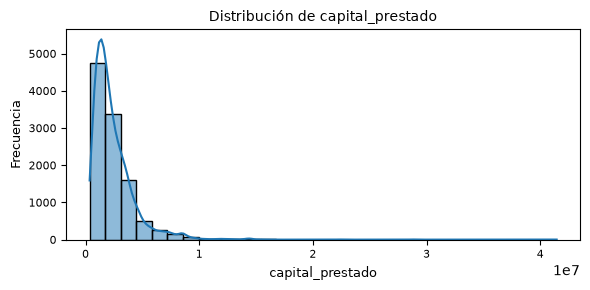

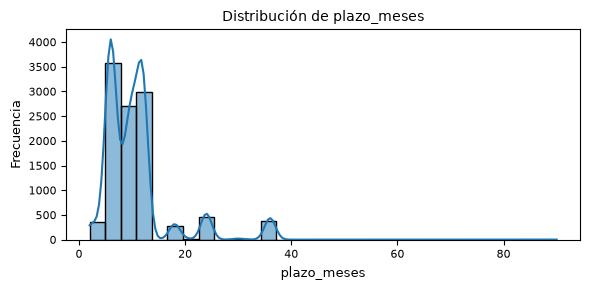

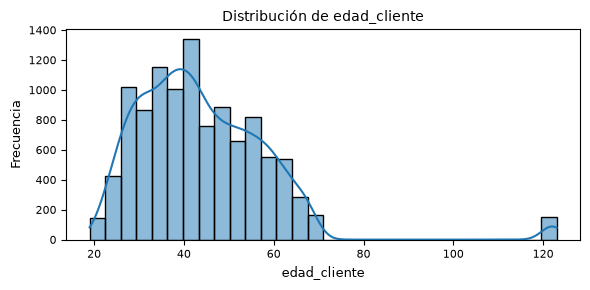

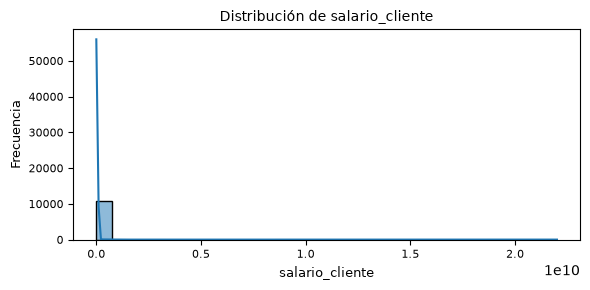

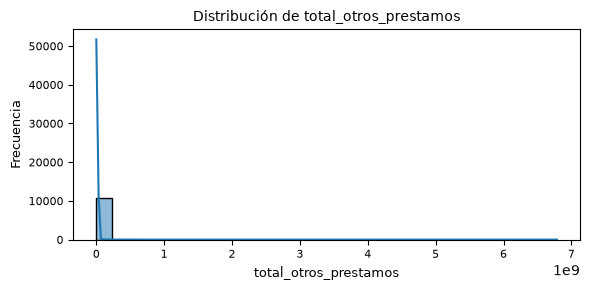

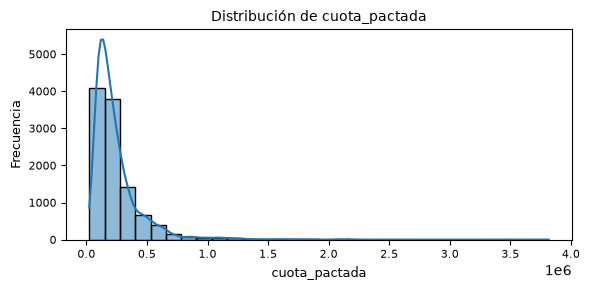

In [37]:
for variable in variables_grupo_1:
    plt.figure(figsize=(6, 3))

    sns.histplot(
        data=df_limpio,
        x=variable,
        bins=30,
        kde=True
    )

    plt.title(f"Distribución de {variable}", fontsize=10)
    plt.xlabel(variable, fontsize=9)
    plt.ylabel("Frecuencia", fontsize=9)
    plt.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

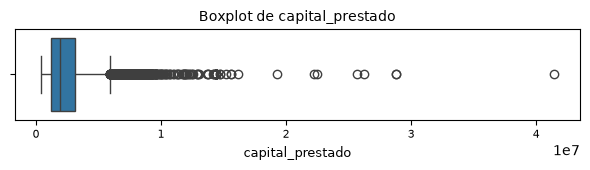

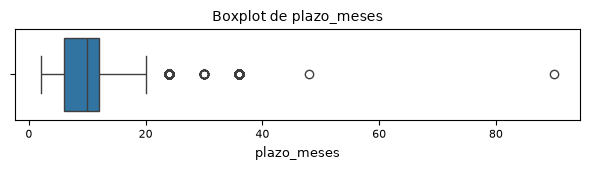

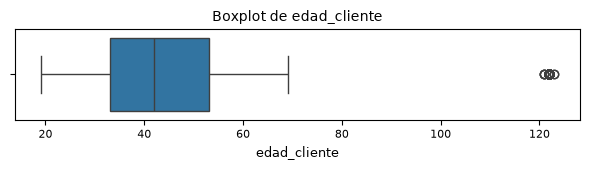

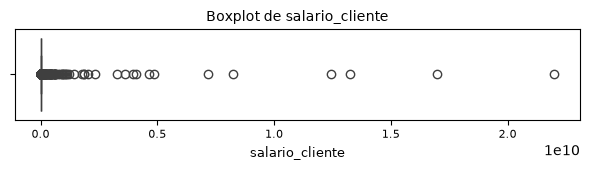

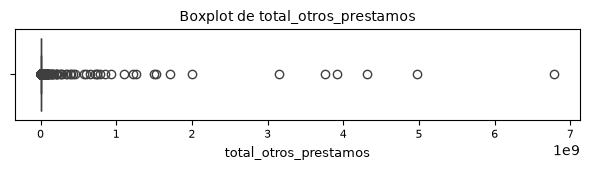

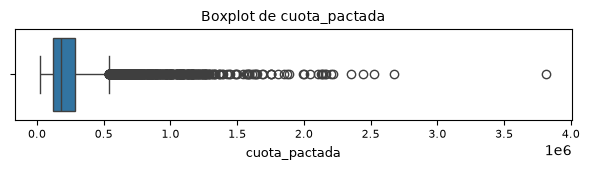

In [38]:
for variable in variables_grupo_1:
    plt.figure(figsize=(6, 1.8))

    sns.boxplot(
        data=df_limpio,
        x=variable
    )

    plt.title(f"Boxplot de {variable}", fontsize=10)
    plt.xlabel(variable, fontsize=9)
    plt.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

##### Revisión específica de `edad_cliente`

La distribución de `edad_cliente` mostró un grupo claramente separado del resto de los datos, con edades superiores a 100 años.

Debido a que estos valores podrían corresponder a una anomalía de calidad, se realiza una inspección específica antes de aplicar cualquier modificación.

In [39]:
edades_altas = df.loc[
    df["edad_cliente"] > 100,
    "edad_cliente"
]

print(f"Registros con edad > 100: {len(edades_altas)}")

print("\nDistribución:")
print(edades_altas.value_counts().sort_index())

Registros con edad > 100: 150

Distribución:
edad_cliente
121      4
122    144
123      2
Name: count, dtype: int64


In [40]:
print("Valores máximos de edad:")

print(
    df["edad_cliente"]
    .value_counts()
    .sort_index()
    .tail(15)
)

Valores máximos de edad:
edad_cliente
58     185
59     187
60     179
61     150
62     136
63     135
64     117
65     101
66      90
67      94
68     109
69      55
121      4
122    144
123      2
Name: count, dtype: int64


In [41]:
indices_edad_invalida = df.index[
    df["edad_cliente"] > 100
]

print(
    "Edades que serán consideradas inválidas:",
    len(indices_edad_invalida)
)

df_limpio.loc[
    indices_edad_invalida,
    "edad_cliente"
] = pd.NA

Edades que serán consideradas inválidas: 150


In [42]:
print("Nulos actuales en edad_cliente:")
print(df_limpio["edad_cliente"].isna().sum())

print("\nEdad mínima:")
print(df_limpio["edad_cliente"].min())

print("\nEdad máxima:")
print(df_limpio["edad_cliente"].max())

print("\nMediana:")
print(df_limpio["edad_cliente"].median())

Nulos actuales en edad_cliente:
150

Edad mínima:
19.0

Edad máxima:
69.0

Mediana:
42.0


##### Actualizar estadísticas de edad_cliente

In [43]:
df_limpio["edad_cliente"].describe().round(2)

count    10613.00
mean        42.85
std         11.95
min         19.00
25%         33.00
50%         42.00
75%         52.00
max         69.00
Name: edad_cliente, dtype: float64

In [44]:
print(
    "Asimetría:",
    round(df_limpio["edad_cliente"].skew(), 2)
)

print(
    "Curtosis:",
    round(df_limpio["edad_cliente"].kurt(), 2)
)

print(
    "Nulos:",
    df_limpio["edad_cliente"].isna().sum()
)

Asimetría: 0.27
Curtosis: -0.86
Nulos: 150


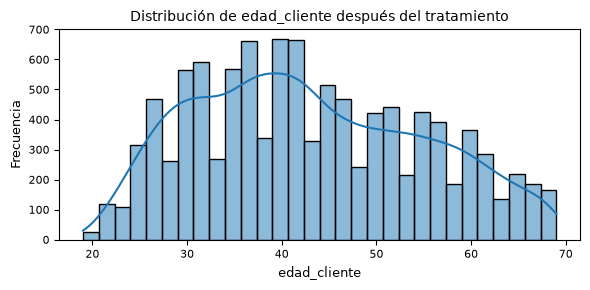

In [45]:
# Visualización posterior al tratamiento - Histograma

plt.figure(figsize=(6, 3))

sns.histplot(
    data=df_limpio,
    x="edad_cliente",
    bins=30,
    kde=True
)

plt.title(
    "Distribución de edad_cliente después del tratamiento",
    fontsize=10
)
plt.xlabel("edad_cliente", fontsize=9)
plt.ylabel("Frecuencia", fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

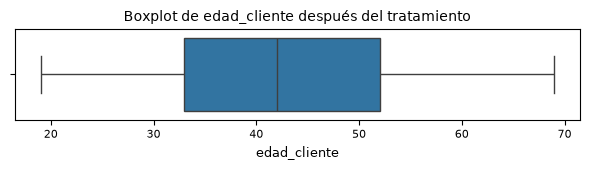

In [46]:
# Visualización posterior al tratamiento - Boxplots


plt.figure(figsize=(6, 1.8))

sns.boxplot(
    data=df_limpio,
    x="edad_cliente"
)

plt.title(
    "Boxplot de edad_cliente después del tratamiento",
    fontsize=10
)
plt.xlabel("edad_cliente", fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

##### Conclusión sobre `edad_cliente`

La revisión específica confirmó que los valores superiores a 100 años estaban concentrados casi exclusivamente en 122 años y generaban una distorsión importante en la distribución.

Luego de considerarlos valores inválidos y representarlos como datos faltantes, `edad_cliente` conserva 10.613 observaciones válidas dentro de un rango de 19 a 69 años. La media pasó a 42,85 años y la mediana se mantuvo en 42 años.

La asimetría disminuyó a 0,27 y la curtosis a -0,86, mostrando que los registros identificados influían considerablemente sobre la forma estadística original de la variable.

##### Valores extremos monetarios

In [47]:
variables_extremos = [
    "capital_prestado",
    "salario_cliente",
    "total_otros_prestamos",
    "cuota_pactada"
]

for variable in variables_extremos:
    print(f"\n{'=' * 60}")
    print(variable)
    print("5 valores más altos:")

    print(
        df_limpio[variable]
        .nlargest(5)
        .to_string(index=False)
    )


capital_prestado
5 valores más altos:
41444153
28800000
28779582
26208019
25657456

salario_cliente
5 valores más altos:
22000000000
16991100000
13258352050
12450806583
 8252584000

total_otros_prestamos
5 valores más altos:
6787675263
4974345404
4316463703
3918433000
3758729000

cuota_pactada
5 valores más altos:
3816752
2671342
2525162
2439394
2355457


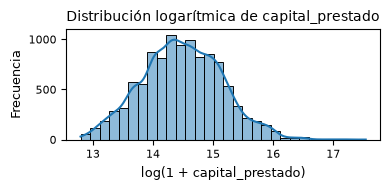

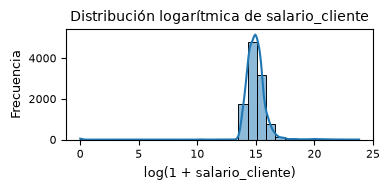

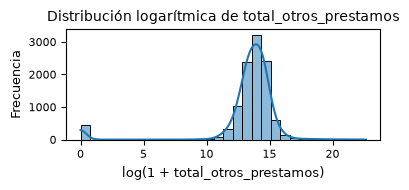

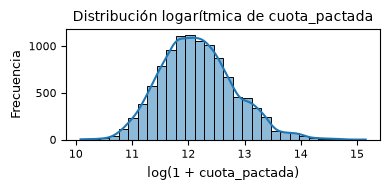

In [48]:
variables_log = [
    "capital_prestado",
    "salario_cliente",
    "total_otros_prestamos",
    "cuota_pactada"
]

for variable in variables_log:
    plt.figure(figsize=(4, 2))

    sns.histplot(
        x=np.log1p(df_limpio[variable].dropna()),
        bins=30,
        kde=True
    )

    plt.title(
        f"Distribución logarítmica de {variable}",
        fontsize=10
    )
    plt.xlabel(f"log(1 + {variable})", fontsize=9)
    plt.ylabel("Frecuencia", fontsize=9)
    plt.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

La visualización mediante `log(1+x)` permitió observar con mayor claridad la estructura central de las variables monetarias cuyos histogramas originales se encontraban fuertemente afectados por valores extremos.

`capital_prestado` y `cuota_pactada` presentan distribuciones mucho más compactas en escala logarítmica, confirmando una fuerte asimetría positiva en la escala original.

En `salario_cliente` y `total_otros_prestamos` se observa además una concentración de registros en cero. Estos valores se conservan en esta etapa, ya que no existe evidencia suficiente para considerarlos errores y su significado deberá analizarse según el contexto de cada variable.

La transformación logarítmica se utilizó exclusivamente con fines exploratorios y no modifica los valores almacenados en `df_limpio`.

##### Puntajes y Comportamiento crediticio

Se analizan por separado las variables de puntaje y las variables que representan cantidades de créditos o consultas.

Las variables de puntaje se estudian como variables numéricas, mientras que las variables de conteo se visualizan como distribuciones discretas.

In [49]:
variables_puntaje = [
    "puntaje",
    "puntaje_datacredito"
]

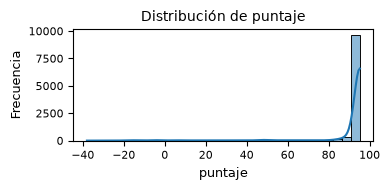

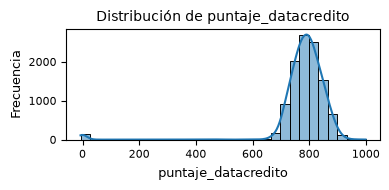

In [50]:
# Histogramas

for variable in variables_puntaje:
    plt.figure(figsize=(4, 2))

    sns.histplot(
        data=df_limpio,
        x=variable,
        bins=30,
        kde=True
    )

    plt.title(f"Distribución de {variable}", fontsize=10)
    plt.xlabel(variable, fontsize=9)
    plt.ylabel("Frecuencia", fontsize=9)
    plt.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

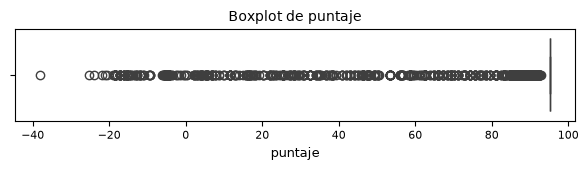

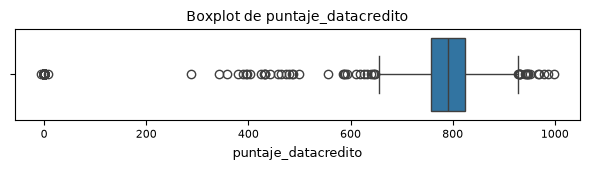

In [51]:
# Boxplots

for variable in variables_puntaje:
    plt.figure(figsize=(6, 1.8))

    sns.boxplot(
        data=df_limpio,
        x=variable
    )

    plt.title(f"Boxplot de {variable}", fontsize=10)
    plt.xlabel(variable, fontsize=9)
    plt.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

##### Variables de conteo

In [52]:
variables_conteo = [
    "cant_creditosvigentes",
    "huella_consulta",
    "creditos_sectorFinanciero",
    "creditos_sectorCooperativo",
    "creditos_sectorReal"
]

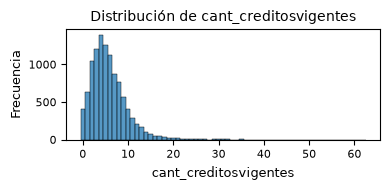

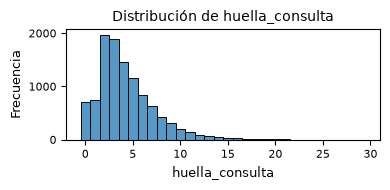

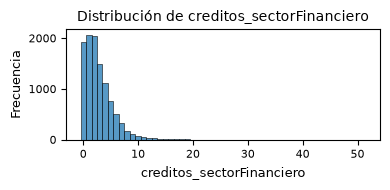

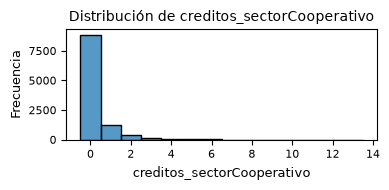

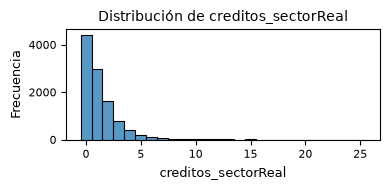

In [53]:
for variable in variables_conteo:
    plt.figure(figsize=(4, 2))

    sns.histplot(
        data=df_limpio,
        x=variable,
        discrete=True
    )

    plt.title(f"Distribución de {variable}", fontsize=10)
    plt.xlabel(variable, fontsize=9)
    plt.ylabel("Frecuencia", fontsize=9)
    plt.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

Las distribuciones de `puntaje` y `puntaje_datacredito` presentan valores considerablemente alejados de sus zonas de mayor concentración.

Antes de considerar cualquier tratamiento, se inspeccionan sus valores mínimos y su frecuencia. Debido a que no se dispone de un diccionario formal que defina el rango válido de estas variables, los valores extremos no serán modificados automáticamente.

In [54]:
print("10 valores más bajos de puntaje:")
print(
    df_limpio["puntaje"]
    .nsmallest(10)
    .to_string(index=False)
)

print("\nCantidad de valores negativos:")
print((df_limpio["puntaje"] < 0).sum())

print("\nCantidad de registros iguales a la moda:")
moda_puntaje = df_limpio["puntaje"].mode().iloc[0]

print((df_limpio["puntaje"] == moda_puntaje).sum())
print("Moda:", moda_puntaje)

10 valores más bajos de puntaje:
-38.009990
-25.210766
-24.036161
-21.864297
-21.099465
-20.630232
-19.004030
-18.471029
-18.471029
-18.471029

Cantidad de valores negativos:
135

Cantidad de registros iguales a la moda:
9407
Moda: 95.227787


In [55]:
print("15 valores más bajos de puntaje_datacredito:")
print(
    df_limpio["puntaje_datacredito"]
    .nsmallest(15)
    .to_string(index=False)
)

print("\nCantidad de valores negativos:")
print((df_limpio["puntaje_datacredito"] < 0).sum())

print("\nCantidad de valores iguales a 0:")
print((df_limpio["puntaje_datacredito"] == 0).sum())

print("\nCantidad de valores menores a 100:")
print((df_limpio["puntaje_datacredito"] < 100).sum())

15 valores más bajos de puntaje_datacredito:
-7.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

Cantidad de valores negativos:
1

Cantidad de valores iguales a 0:
145

Cantidad de valores menores a 100:
147


`puntaje` presenta una concentración muy elevada en el valor 95,227787, que corresponde a 9.407 registros. Esta concentración provoca que el primer cuartil, la mediana y el tercer cuartil prácticamente coincidan y que el IQR sea igual a cero. Por este motivo, los puntos señalados por el boxplot no pueden interpretarse automáticamente como errores.

También se identificaron 135 valores negativos en esta variable.

En `puntaje_datacredito` se observó un pequeño conjunto de valores considerablemente inferior a la distribución principal: existe un valor negativo, 145 registros iguales a cero y 147 registros inferiores a 100.

Debido a que no se dispone de un diccionario de datos que establezca los rangos válidos o el significado de estos valores especiales, no se realizan modificaciones sobre ninguna de las dos variables. Los casos quedan documentados para una eventual validación con la fuente de datos.

##### Saldos e Ingresos

In [56]:
variables_grupo_3 = [
    "saldo_mora",
    "saldo_total",
    "saldo_principal",
    "saldo_mora_codeudor",
    "promedio_ingresos_datacredito"
]

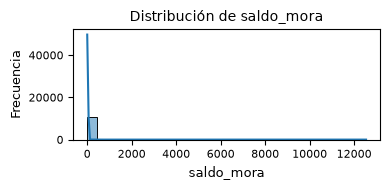

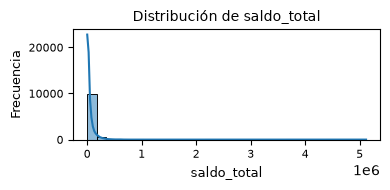

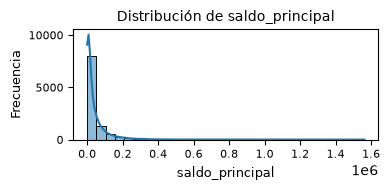

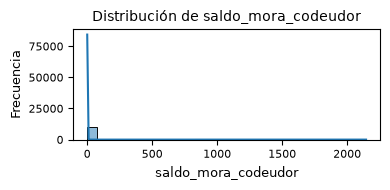

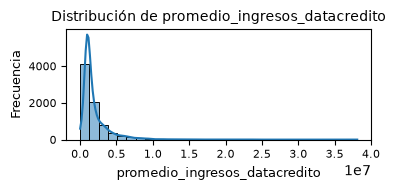

In [57]:
for variable in variables_grupo_3:
    plt.figure(figsize=(4, 2))

    sns.histplot(
        data=df_limpio,
        x=variable,
        bins=30,
        kde=True
    )

    plt.title(f"Distribución de {variable}", fontsize=10)
    plt.xlabel(variable, fontsize=9)
    plt.ylabel("Frecuencia", fontsize=9)
    plt.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

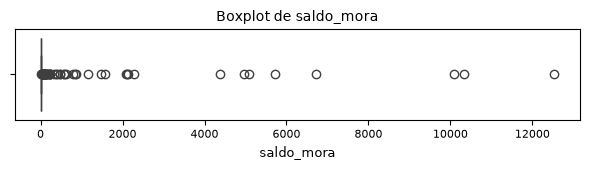

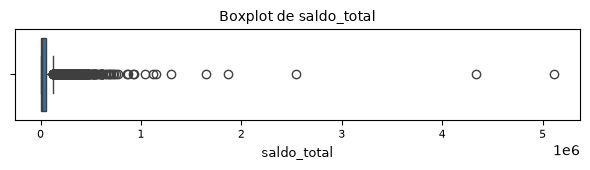

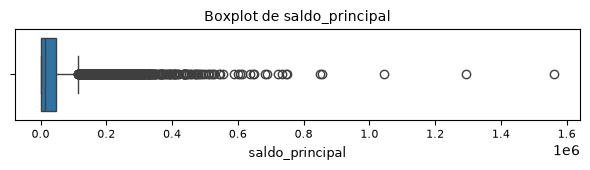

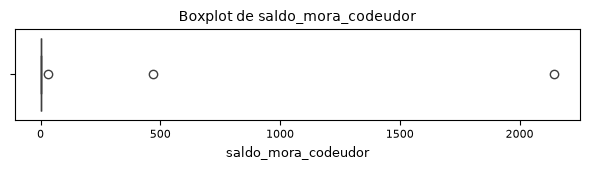

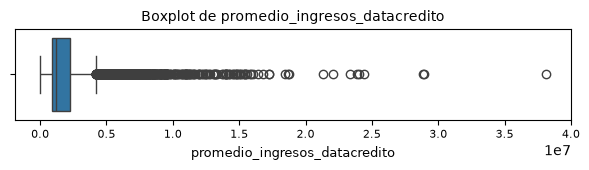

In [58]:
for variable in variables_grupo_3:
    plt.figure(figsize=(6, 1.8))

    sns.boxplot(
        data=df_limpio,
        x=variable
    )

    plt.title(f"Boxplot de {variable}", fontsize=10)
    plt.xlabel(variable, fontsize=9)
    plt.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

In [59]:
resumen_ceros_nulos = pd.DataFrame({
    "ceros": [
        (df_limpio[var] == 0).sum()
        for var in variables_grupo_3
    ],
    "nulos": [
        df_limpio[var].isna().sum()
        for var in variables_grupo_3
    ]
}, index=variables_grupo_3)

resumen_ceros_nulos["porcentaje_ceros"] = (
    resumen_ceros_nulos["ceros"] / len(df_limpio) * 100
).round(2)

resumen_ceros_nulos["porcentaje_nulos"] = (
    resumen_ceros_nulos["nulos"] / len(df_limpio) * 100
).round(2)

resumen_ceros_nulos

,ceros,nulos,porcentaje_ceros,porcentaje_nulos
saldo_mora,10552,156,98.04,1.45
saldo_total,789,156,7.33,1.45
saldo_principal,633,405,5.88,3.76
saldo_mora_codeudor,10170,590,94.49,5.48
promedio_ingresos_datacredito,7,2930,0.07,27.22


`saldo_mora` y `saldo_mora_codeudor` presentan una proporción muy elevada de valores iguales a cero. En estos casos, el boxplot tradicional tiene capacidad limitada para representar adecuadamente la distribución, ya que el IQR también resulta igual a cero.

Por este motivo, se analiza de forma complementaria la proporción de registros con valor cero, positivo y faltante, y se observa por separado la distribución de los valores positivos.

In [60]:
for variable in ["saldo_mora", "saldo_mora_codeudor"]:

    total = len(df_limpio)

    cantidad_ceros = (df_limpio[variable] == 0).sum()
    cantidad_positivos = (df_limpio[variable] > 0).sum()
    cantidad_nulos = df_limpio[variable].isna().sum()

    print(f"\n{'=' * 50}")
    print(variable)

    print(
        f"Ceros: {cantidad_ceros} "
        f"({cantidad_ceros / total * 100:.2f}%)"
    )

    print(
        f"Positivos: {cantidad_positivos} "
        f"({cantidad_positivos / total * 100:.2f}%)"
    )

    print(
        f"Nulos: {cantidad_nulos} "
        f"({cantidad_nulos / total * 100:.2f}%)"
    )


saldo_mora
Ceros: 10552 (98.04%)
Positivos: 55 (0.51%)
Nulos: 156 (1.45%)

saldo_mora_codeudor
Ceros: 10170 (94.49%)
Positivos: 3 (0.03%)
Nulos: 590 (5.48%)


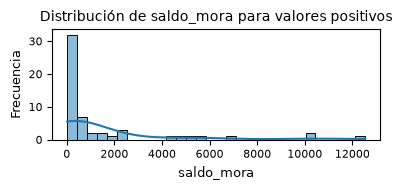

In [61]:
saldo_mora_positivo = df_limpio.loc[
    df_limpio["saldo_mora"] > 0,
    "saldo_mora"
]

plt.figure(figsize=(4, 2))

sns.histplot(
    saldo_mora_positivo,
    bins=30,
    kde=True
)

plt.title(
    "Distribución de saldo_mora para valores positivos",
    fontsize=10
)
plt.xlabel("saldo_mora", fontsize=9)
plt.ylabel("Frecuencia", fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

In [62]:
print("Valores positivos de saldo_mora_codeudor:")

print(
    df_limpio.loc[
        df_limpio["saldo_mora_codeudor"] > 0,
        "saldo_mora_codeudor"
    ].sort_values()
)

Valores positivos de saldo_mora_codeudor:
2032      30.0
8586     470.0
460     2145.0
Name: saldo_mora_codeudor, dtype: float64


##### Conclusiones sobre saldos e ingresos

Las variables relacionadas con saldos presentan distribuciones fuertemente asimétricas.

`saldo_mora` se encuentra especialmente concentrada en cero, con el 98,04 % de los registros en ese valor. De manera similar, `saldo_mora_codeudor` presenta un 94,49 % de ceros y únicamente tres registros con saldos positivos. Debido a esta concentración, los boxplots de estas variables deben interpretarse con precaución, ya que los valores positivos aparecen como extremos estadísticos sin que ello implique necesariamente que sean errores.

`saldo_total` y `saldo_principal` presentan una mayor variabilidad, aunque también muestran colas hacia valores elevados.

Por otra parte, `promedio_ingresos_datacredito` presenta un 27,22 % de valores faltantes y una distribución con asimetría positiva. Los valores faltantes se mantienen sin imputar hasta definir posteriormente una estrategia basada en el uso que tendrá la variable durante el modelado.

No se eliminaron valores únicamente por haber sido identificados como extremos estadísticos.

#### Variables Categóricas

In [63]:
variables_categoricas = [
    "tipo_credito",
    "tipo_laboral",
    "tendencia_ingresos",
    "Pago_atiempo"
]

Las variables categóricas se analizan mediante sus frecuencias absolutas y relativas, permitiendo identificar las categorías existentes, su representación dentro del dataset y posibles desbalances.

Se incluyen `tipo_credito`, `tipo_laboral`, `tendencia_ingresos` y `Pago_atiempo`. Esta última se encuentra almacenada como 0/1, pero se analiza conceptualmente como una variable categórica binaria y posible variable objetivo.

In [64]:
for variable in variables_categoricas:
    
    frecuencia = df_limpio[variable].value_counts(
        dropna=False
    )
    
    porcentaje = (
        df_limpio[variable]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .mul(100)
        .round(2)
    )
    
    resumen = pd.DataFrame({
        "cantidad": frecuencia,
        "porcentaje": porcentaje
    })
    
    print(f"\n{'=' * 60}")
    print(f"Variable: {variable}")
    display(resumen)


Variable: tipo_credito


,cantidad,porcentaje
tipo_credito,,
4,7747,71.98
9,2876,26.72
10,116,1.08
6,21,0.20
7,2,0.02
68,1,0.01



Variable: tipo_laboral


,cantidad,porcentaje
tipo_laboral,,
Empleado,6754,62.75
Independiente,4009,37.25



Variable: tendencia_ingresos


,cantidad,porcentaje
tendencia_ingresos,,
Creciente,5294,49.19
NaN,2990,27.78
Decreciente,1291,11.99
Estable,1188,11.04



Variable: Pago_atiempo


,cantidad,porcentaje
Pago_atiempo,,
1,10252,95.25
0,511,4.75


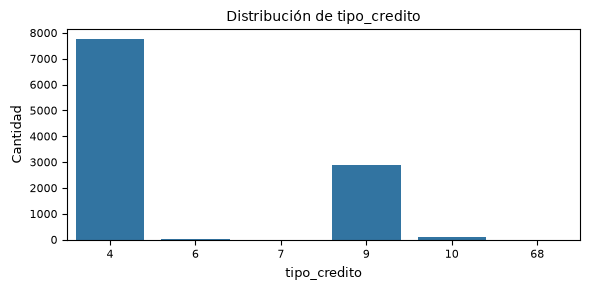

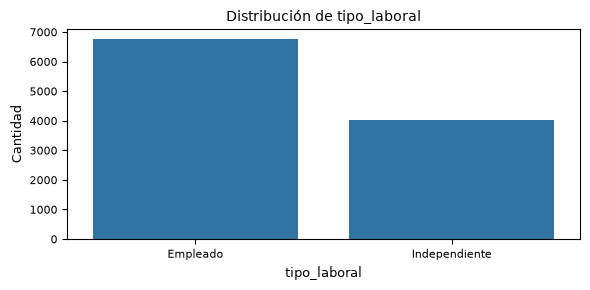

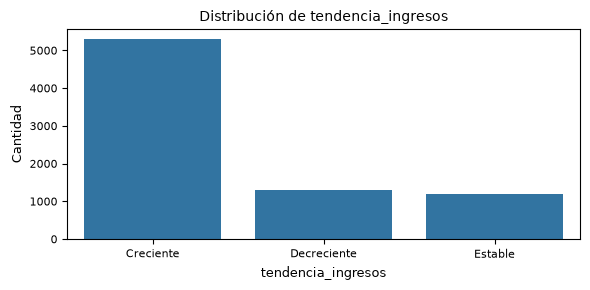

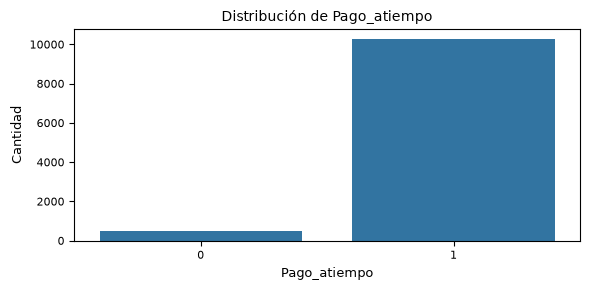

In [65]:
for variable in variables_categoricas:
    plt.figure(figsize=(6, 3))

    sns.countplot(
        data=df_limpio,
        x=variable
    )

    plt.title(
        f"Distribución de {variable}",
        fontsize=10
    )
    plt.xlabel(variable, fontsize=9)
    plt.ylabel("Cantidad", fontsize=9)
    plt.tick_params(axis="x", labelsize=8)
    plt.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.show()

El análisis de frecuencias muestra que `tipo_credito` se encuentra fuertemente concentrada en los códigos 4 (71,98 %) y 9 (26,72 %). Los demás códigos presentan una frecuencia muy baja, incluyendo el valor 68, observado en un único registro. Este valor se conserva debido a que no se dispone de información suficiente para determinar que sea incorrecto.

En `tipo_laboral`, el 62,75 % de los registros corresponde a clientes empleados y el 37,25 % a clientes independientes, por lo que ambas categorías cuentan con una representación significativa.

`tendencia_ingresos` presenta un predominio de la categoría `Creciente` (49,19 % del total), mientras que `Decreciente` y `Estable` representan el 11,99 % y 11,04 %, respectivamente. Además, la variable mantiene un 27,78 % de valores faltantes, lo que deberá considerarse en análisis posteriores.

Finalmente, `Pago_atiempo`, considerada preliminarmente la variable objetivo, presenta un fuerte desbalance entre clases: el 95,25 % de los registros pertenece a la clase 1 y solamente el 4,75 % a la clase 0. Este desbalance deberá ser tenido en cuenta posteriormente durante el entrenamiento y evaluación de los modelos.

##### Análisis Temporal de `fecha_prestamo`

La variable `fecha_prestamo` se analiza para conocer el período cubierto por el dataset y observar la evolución del volumen de préstamos a lo largo del tiempo.

In [66]:
print("Fecha mínima:")
print(df_limpio["fecha_prestamo"].min())

print("\nFecha máxima:")
print(df_limpio["fecha_prestamo"].max())

print("\nCantidad de fechas y horas únicas:")
print(df_limpio["fecha_prestamo"].nunique())

Fecha mínima:
2024-11-26 09:17:00

Fecha máxima:
2026-04-26 18:43:00

Cantidad de fechas y horas únicas:
10444


In [67]:
# Cantidad de préstamos por mes

prestamos_por_mes = (
    df_limpio
    .set_index("fecha_prestamo")
    .resample("ME")
    .size()
)

prestamos_por_mes

fecha_prestamo
2024-11-30     186
2024-12-31    1216
2025-01-31    1917
2025-02-28    1094
2025-03-31    1115
2025-04-30    1102
2025-05-31    1083
2025-06-30     665
2025-07-31     644
2025-08-31     555
2025-09-30     361
2025-10-31     231
2025-11-30     166
2025-12-31     174
2026-01-31     127
2026-02-28      76
2026-03-31      40
2026-04-30      11
Freq: ME, dtype: int64

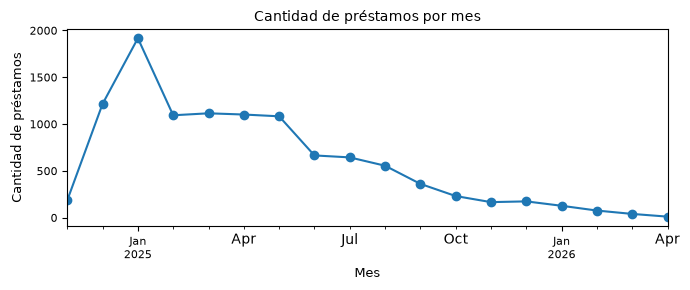

In [68]:
plt.figure(figsize=(7, 3))

prestamos_por_mes.plot(marker="o")

plt.title("Cantidad de préstamos por mes", fontsize=10)
plt.xlabel("Mes", fontsize=9)
plt.ylabel("Cantidad de préstamos", fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

In [69]:
# Cantidad de préstamos por día

prestamos_por_dia = (
    df_limpio["fecha_prestamo"]
    .dt.day_name()
    .value_counts()
)

prestamos_por_dia

fecha_prestamo
Thursday     1899
Friday       1789
Saturday     1621
Sunday       1481
Tuesday      1412
Monday       1307
Wednesday    1254
Name: count, dtype: int64

In [70]:
orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

prestamos_por_dia = (
    df_limpio["fecha_prestamo"]
    .dt.day_name()
    .value_counts()
    .reindex(orden_dias)
)

prestamos_por_dia

fecha_prestamo
Monday       1307
Tuesday      1412
Wednesday    1254
Thursday     1899
Friday       1789
Saturday     1621
Sunday       1481
Name: count, dtype: int64

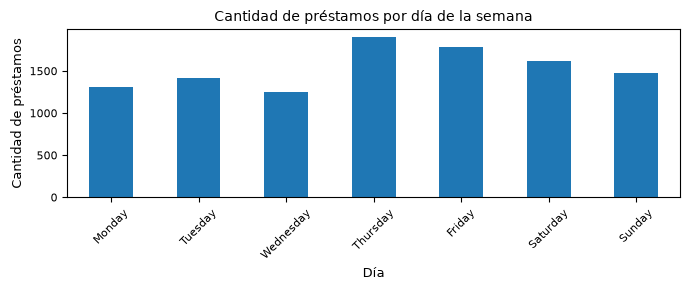

In [71]:
plt.figure(figsize=(7, 3))

prestamos_por_dia.plot(kind="bar")

plt.title("Cantidad de préstamos por día de la semana", fontsize=10)
plt.xlabel("Día", fontsize=9)
plt.ylabel("Cantidad de préstamos", fontsize=9)
plt.xticks(rotation=45)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

El dataset contiene operaciones registradas entre el 26 de noviembre de 2024 y el 26 de abril de 2026.

El volumen mensual presenta su máximo en enero de 2025 y posteriormente muestra una reducción progresiva, especialmente a partir de mediados de 2025. Los meses inicial y final corresponden a períodos parciales y, por lo tanto, sus cantidades no deben compararse directamente con meses completos.

Este comportamiento evidencia una estructura temporal en los datos, aunque no se dispone de información suficiente para determinar si la reducción observada corresponde a un fenómeno real del negocio o al proceso mediante el cual fue construido el dataset.

También se observan operaciones durante los siete días de la semana, con mayores cantidades los jueves y viernes. Este patrón se documenta sin atribuirle todavía una relación con la variable objetivo.

La fecha podría utilizarse posteriormente para generar atributos derivados, como mes o día de la semana, dentro de una etapa de feature engineering.

##### Conclusiones generales del análisis univariado

El análisis univariado permitió caracterizar individualmente las variables numéricas, categóricas y temporales del dataset e identificar aspectos relevantes para las siguientes etapas del proyecto.

Las variables monetarias presentan, en general, distribuciones asimétricas hacia valores elevados. Algunas, como `salario_cliente`, `total_otros_prestamos`, `capital_prestado` y `cuota_pactada`, contienen valores extremos que afectan considerablemente sus escalas. Estos registros fueron conservados debido a que no existe evidencia suficiente para considerarlos errores. Las visualizaciones logarítmicas permitieron estudiar con mayor claridad sus distribuciones centrales sin modificar los datos originales.

Durante el análisis de `edad_cliente` se detectó una anomalía particular: 150 registros presentaban edades superiores a 100 años y 144 de ellos tenían exactamente 122 años. Debido al patrón sistemático observado, estos valores fueron considerados inconsistentes y representados como datos faltantes en `df_limpio`. Luego del tratamiento, las edades válidas se encuentran entre 19 y 69 años.

Las variables `puntaje` y `puntaje_datacredito` contienen valores alejados de sus distribuciones principales. Sin embargo, al no disponer de documentación sobre sus escalas válidas, estos registros fueron conservados y documentados en lugar de modificarlos arbitrariamente.

Las variables relacionadas con mora presentan una concentración especialmente elevada en cero. `saldo_mora` contiene un 98,04 % de ceros y `saldo_mora_codeudor` un 94,49 %. Por este motivo, los valores positivos pueden aparecer como extremos en un boxplot sin implicar necesariamente errores.

Entre las variables categóricas, `tipo_credito` está concentrada principalmente en los códigos 4 y 9, mientras que `tipo_laboral` contiene una representación significativa tanto de empleados como de independientes. `tendencia_ingresos` mantiene un 27,78 % de valores faltantes.

La posible variable objetivo, `Pago_atiempo`, presenta un fuerte desbalance: el 95,25 % de los registros pertenece a la clase 1 y solamente el 4,75 % a la clase 0. Este aspecto deberá considerarse especialmente durante el entrenamiento y evaluación de los modelos.

Finalmente, `fecha_prestamo` evidencia una estructura temporal, con una reducción progresiva del volumen mensual después de comienzos de 2025. También se identificó la posibilidad de generar posteriormente atributos derivados de la fecha dentro de una etapa de feature engineering.

En esta etapa no se eliminaron valores únicamente por ser extremos estadísticos ni se imputaron automáticamente los valores faltantes. Las decisiones de tratamiento se realizaron únicamente cuando existía evidencia suficiente para justificarlas.

### Análsis Bivariado

El análisis bivariado estudia la relación entre dos variables. En esta etapa se analizará cómo se comportan las distintas características del dataset con respecto a `Pago_atiempo`, considerada la variable objetivo del problema.

Debido al fuerte desbalance observado previamente en la variable objetivo, las comparaciones no se realizarán únicamente mediante cantidades absolutas. También se utilizarán estadísticas por clase y proporciones relativas para evitar interpretaciones condicionadas por el mayor tamaño de la clase predominante.

El objetivo de esta etapa es identificar características que presenten comportamientos diferentes entre las clases, sin asumir relaciones causales.

In [72]:
# Variable Objetivo

distribucion_objetivo = (
    df_limpio["Pago_atiempo"]
    .value_counts()
    .sort_index()
)

porcentaje_objetivo = (
    df_limpio["Pago_atiempo"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

pd.DataFrame({
    "cantidad": distribucion_objetivo,
    "porcentaje": porcentaje_objetivo
})

,cantidad,porcentaje
Pago_atiempo,,
0,511,4.75
1,10252,95.25


#### Variables numéricas vs `Pago_atiempo`

In [73]:
# Comparación de medianas

medianas_por_clase = (
    df_limpio
    .groupby("Pago_atiempo")[variables_numericas]
    .median()
    .T
)

medianas_por_clase.columns = [
    "mediana_pago_0",
    "mediana_pago_1"
]

medianas_por_clase["diferencia"] = (
    medianas_por_clase["mediana_pago_1"]
    - medianas_por_clase["mediana_pago_0"]
)

medianas_por_clase.round(2)

,mediana_pago_0,mediana_pago_1,diferencia
capital_prestado,2268000.00,1908446.50,-359553.50
plazo_meses,10.00,10.00,0.00
edad_cliente,37.00,42.00,5.00
salario_cliente,3000000.00,3000000.00,0.00
total_otros_prestamos,900000.00,1000000.00,100000.00
cuota_pactada,199002.00,182576.00,-16426.00
puntaje,25.42,95.23,69.81
puntaje_datacredito,768.00,792.00,24.00
cant_creditosvigentes,5.00,5.00,0.00
huella_consulta,5.00,4.00,-1.00


In [74]:
# Comparación de medias

medias_por_clase = (
    df_limpio
    .groupby("Pago_atiempo")[variables_numericas]
    .mean()
    .T
)

medias_por_clase.columns = [
    "media_pago_0",
    "media_pago_1"
]

medias_por_clase["diferencia"] = (
    medias_por_clase["media_pago_1"]
    - medias_por_clase["media_pago_0"]
)

medias_por_clase.round(2)

,media_pago_0,media_pago_1,diferencia
capital_prestado,2781774.11,2416996.27,-364777.85
plazo_meses,12.45,10.48,-1.97
edad_cliente,40.01,42.99,2.98
salario_cliente,23555143.33,16900485.13,-6654658.20
total_otros_prestamos,11564401.93,5973424.18,-5590977.75
cuota_pactada,254755.69,243062.23,-11693.46
puntaje,23.09,94.56,71.47
puntaje_datacredito,748.88,782.38,33.50
cant_creditosvigentes,5.57,5.73,0.17
huella_consulta,5.24,4.18,-1.06


In [75]:
# Cantidad válida usada por cada clase

conteos_por_clase = (
    df_limpio
    .groupby("Pago_atiempo")[variables_numericas]
    .count()
    .T
)

conteos_por_clase.columns = [
    "registros_validos_pago_0",
    "registros_validos_pago_1"
]

conteos_por_clase

,registros_validos_pago_0,registros_validos_pago_1
capital_prestado,511,10252
plazo_meses,511,10252
edad_cliente,500,10113
salario_cliente,511,10252
total_otros_prestamos,511,10252
cuota_pactada,511,10252
puntaje,511,10252
puntaje_datacredito,510,10247
cant_creditosvigentes,511,10252
huella_consulta,511,10252


In [76]:
# Resumen

resumen_numericas_objetivo = pd.concat(
    [
        conteos_por_clase,
        medianas_por_clase[
            ["mediana_pago_0", "mediana_pago_1"]
        ],
        medias_por_clase[
            ["media_pago_0", "media_pago_1"]
        ]
    ],
    axis=1
)

resumen_numericas_objetivo.round(2)

,registros_validos_pago_0,registros_validos_pago_1,mediana_pago_0,mediana_pago_1,media_pago_0,media_pago_1
capital_prestado,511,10252,2268000.00,1908446.50,2781774.11,2416996.27
plazo_meses,511,10252,10.00,10.00,12.45,10.48
edad_cliente,500,10113,37.00,42.00,40.01,42.99
salario_cliente,511,10252,3000000.00,3000000.00,23555143.33,16900485.13
total_otros_prestamos,511,10252,900000.00,1000000.00,11564401.93,5973424.18
cuota_pactada,511,10252,199002.00,182576.00,254755.69,243062.23
puntaje,511,10252,25.42,95.23,23.09,94.56
puntaje_datacredito,510,10247,768.00,792.00,748.88,782.38
cant_creditosvigentes,511,10252,5.00,5.00,5.57,5.73
huella_consulta,511,10252,5.00,4.00,5.24,4.18


##### Visualización

In [77]:
variables_bivariadas_principales = [
    "puntaje",
    "puntaje_datacredito",
    "edad_cliente",
    "huella_consulta",
    "capital_prestado",
    "cuota_pactada",
    "promedio_ingresos_datacredito"
]

###### Comparación de variables numéricas con la variable objetivo

A partir de las estadísticas agrupadas por `Pago_atiempo`, se seleccionan algunas variables que presentan diferencias entre las clases para profundizar su análisis gráfico.

Los gráficos permiten comparar sus distribuciones, aunque las diferencias observadas se interpretan como asociaciones dentro del dataset y no como relaciones causales.

In [78]:
variables_bivariadas_principales = [
    "puntaje",
    "puntaje_datacredito",
    "edad_cliente",
    "huella_consulta",
    "capital_prestado",
    "cuota_pactada",
    "promedio_ingresos_datacredito"
]

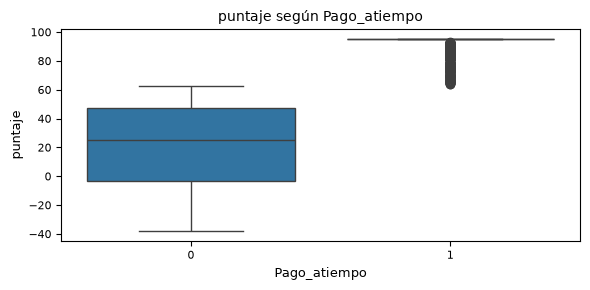

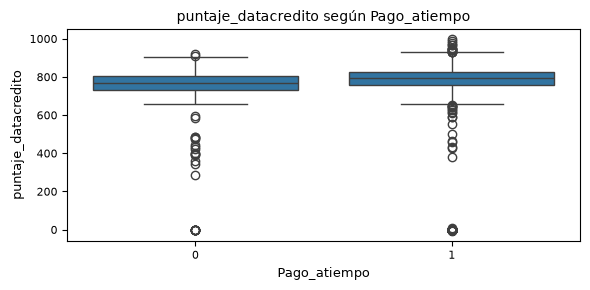

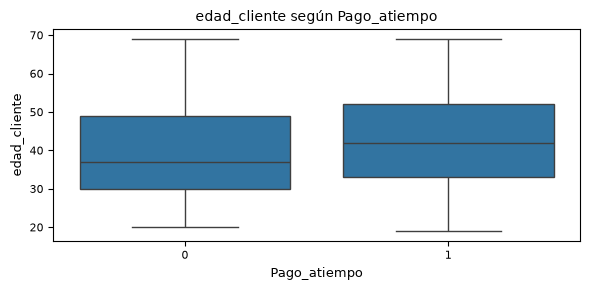

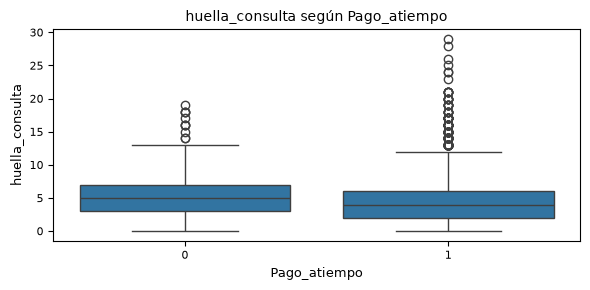

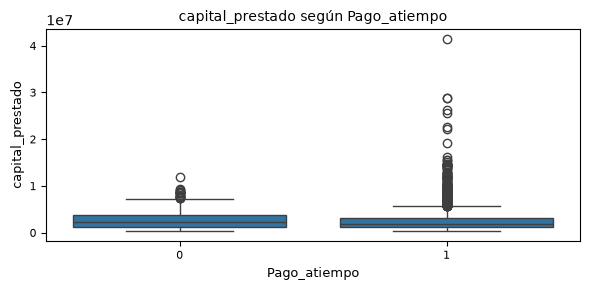

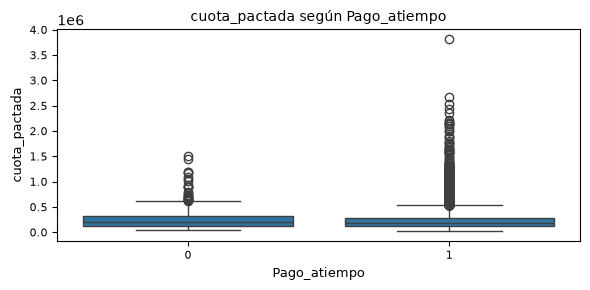

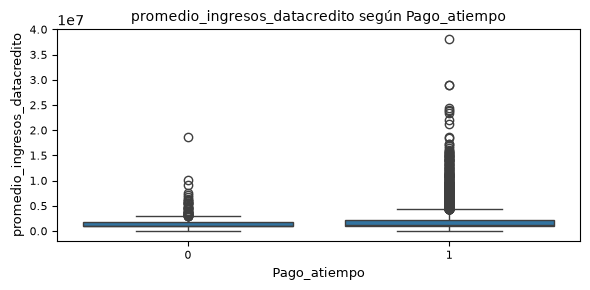

In [79]:
for variable in variables_bivariadas_principales:
    plt.figure(figsize=(6, 3))

    sns.boxplot(
        data=df_limpio,
        x="Pago_atiempo",
        y=variable
    )

    plt.title(
        f"{variable} según Pago_atiempo",
        fontsize=10
    )
    plt.xlabel("Pago_atiempo", fontsize=9)
    plt.ylabel(variable, fontsize=9)
    plt.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

#### Análisis `saldo_mora`

In [80]:
resumen_mora_objetivo = (
    df_limpio
    .assign(
        tiene_mora=df_limpio["saldo_mora"] > 0
    )
    .groupby("Pago_atiempo")["tiene_mora"]
    .agg(["sum", "count"])
)

resumen_mora_objetivo["porcentaje_con_mora"] = (
    resumen_mora_objetivo["sum"]
    / resumen_mora_objetivo["count"]
    * 100
).round(2)

resumen_mora_objetivo.rename(
    columns={
        "sum": "cantidad_con_mora",
        "count": "cantidad_total"
    }
)

,cantidad_con_mora,cantidad_total,porcentaje_con_mora
Pago_atiempo,,,
0,20,511,3.91
1,35,10252,0.34


In [81]:
mora_valida = df_limpio[
    df_limpio["saldo_mora"].notna()
].copy()

resumen_mora_objetivo = (
    mora_valida
    .assign(
        tiene_mora=mora_valida["saldo_mora"] > 0
    )
    .groupby("Pago_atiempo")["tiene_mora"]
    .agg(["sum", "count"])
)

resumen_mora_objetivo["porcentaje_con_mora"] = (
    resumen_mora_objetivo["sum"]
    / resumen_mora_objetivo["count"]
    * 100
).round(2)

resumen_mora_objetivo = resumen_mora_objetivo.rename(
    columns={
        "sum": "cantidad_con_mora",
        "count": "registros_validos"
    }
)

resumen_mora_objetivo

,cantidad_con_mora,registros_validos,porcentaje_con_mora
Pago_atiempo,,,
0,20,500,4.00
1,35,10107,0.35


#### Conclusiones del análisis bivariado de variables numéricas

La comparación de las variables numéricas respecto de `Pago_atiempo` permitió identificar diferencias de distinta magnitud entre las clases.

`puntaje` presenta la separación más marcada: la mediana es aproximadamente 25,42 para la clase 0 y 95,23 para la clase 1. La diferencia también aparece en las medias y en la representación gráfica, por lo que se identifica como una variable especialmente asociada con el comportamiento de pago.

`puntaje_datacredito`, `edad_cliente` y `huella_consulta` también presentan diferencias consistentes entre clases, aunque con mayor solapamiento en sus distribuciones.

Las variables monetarias como `capital_prestado`, `cuota_pactada` y `promedio_ingresos_datacredito` presentan diferencias en sus estadísticas agrupadas, pero también fuerte dispersión, valores extremos y considerable solapamiento entre las clases, por lo que su interpretación debe realizarse con cautela.

En `saldo_mora`, la mediana es cero para ambas clases debido a la elevada concentración de registros sin mora. Sin embargo, al analizar específicamente la presencia de valores positivos se observa que el 4,00 % de los registros válidos de la clase 0 presenta mora, frente al 0,35 % de la clase 1.

Las diferencias observadas representan asociaciones dentro del dataset y no implican relaciones causales.

#### Variables categóricas vs `Pago_atiempo`

Para estudiar la relación entre las variables categóricas y `Pago_atiempo` se utilizanrán tablas cruzadas.

Debido al fuerte desbalance de la variable objetivo, además de las frecuencias absolutas se calculan porcentajes dentro de cada categoría. Esto permite comparar la proporción de las clases sin que el diferente tamaño de los grupos distorsione la interpretación.

Los valores faltantes de `tendencia_ingresos` se mantienen como una categoría de análisis denominada `Faltante`, únicamente para estudiar si la ausencia de información presenta un comportamiento diferente respecto de la variable objetivo.

In [82]:
variables_categoricas_predictoras = [
    "tipo_credito",
    "tipo_laboral",
    "tendencia_ingresos"
]

In [83]:
# Tablas cruzadas

for variable in variables_categoricas_predictoras:

    # Convertir temporalmente los NaN en una categoría visible
    variable_analisis = (
        df_limpio[variable]
        .astype("object")
        .fillna("Faltante")
    )

    tabla = pd.crosstab(
        variable_analisis,
        df_limpio["Pago_atiempo"]
    )

    tabla["total"] = tabla.sum(axis=1)

    tabla["porcentaje_pago_0"] = (
        tabla[0] / tabla["total"] * 100
    ).round(2)

    tabla["porcentaje_pago_1"] = (
        tabla[1] / tabla["total"] * 100
    ).round(2)

    print(f"\n{'=' * 60}")
    print(f"Variable: {variable}")

    display(tabla)


Variable: tipo_credito


Pago_atiempo,0,1,total,porcentaje_pago_0,porcentaje_pago_1
tipo_credito,,,,,
4,363,7384,7747,4.69,95.31
6,9,12,21,42.86,57.14
7,0,2,2,0.00,100.00
9,136,2740,2876,4.73,95.27
10,3,113,116,2.59,97.41
68,0,1,1,0.00,100.00



Variable: tipo_laboral


Pago_atiempo,0,1,total,porcentaje_pago_0,porcentaje_pago_1
tipo_laboral,,,,,
Empleado,290,6464,6754,4.29,95.71
Independiente,221,3788,4009,5.51,94.49



Variable: tendencia_ingresos


Pago_atiempo,0,1,total,porcentaje_pago_0,porcentaje_pago_1
tendencia_ingresos,,,,,
Creciente,207,5087,5294,3.91,96.09
Decreciente,81,1210,1291,6.27,93.73
Estable,55,1133,1188,4.63,95.37
Faltante,168,2822,2990,5.62,94.38


#### Conclusiones sobre las variables categóricas y la variable objetivo

Las tablas cruzadas permiten comparar el comportamiento de `Pago_atiempo` dentro de cada categoría evitando que el fuerte desbalance general de la variable objetivo distorsione la interpretación.

En `tipo_credito`, los códigos 4 y 9, que concentran la gran mayoría de los registros, presentan proporciones de clase 0 prácticamente idénticas, de 4,69 % y 4,73 % respectivamente. El código 6 presenta una proporción considerablemente mayor de clase 0 (42,86 %), aunque este resultado debe interpretarse con cautela debido a que corresponde únicamente a 21 observaciones. De manera similar, los códigos con muy pocos registros no permiten obtener conclusiones robustas.

En `tipo_laboral`, los clientes independientes presentan una proporción de clase 0 del 5,51 %, frente al 4,29 % observado entre los empleados. La diferencia existe, aunque es moderada.

`tendencia_ingresos` presenta un patrón más marcado. Los registros clasificados como `Creciente` muestran la menor proporción de clase 0 (3,91 %), mientras que `Decreciente` presenta la mayor (6,27 %). Los registros con información faltante alcanzan un 5,62 % de clase 0, lo que sugiere que la ausencia de esta información podría no ser completamente independiente del comportamiento de pago.

Las diferencias identificadas representan asociaciones observadas en este dataset y no implican relaciones causales.

##### Visualización

Para complementar las tablas cruzadas se representa gráficamente el porcentaje de registros pertenecientes a la clase 0 dentro de cada categoría.

Esta visualización resulta más informativa que las frecuencias absolutas debido al fuerte desbalance de `Pago_atiempo`.

In [84]:
def graficar_porcentaje_clase_0(dataframe, variable):

    datos = dataframe[[variable, "Pago_atiempo"]].copy()

    # Mostrar los valores faltantes como una categoría visible
    datos[variable] = (
        datos[variable]
        .astype("object")
        .fillna("Faltante")
    )

    resumen = (
        datos
        .groupby(variable, observed=False)["Pago_atiempo"]
        .apply(lambda x: (x == 0).mean() * 100)
        .sort_values()
    )

    plt.figure(figsize=(6, 3))

    resumen.plot(kind="bar")

    plt.title(
        f"Porcentaje de clase 0 según {variable}",
        fontsize=10
    )
    plt.xlabel(variable, fontsize=9)
    plt.ylabel("Porcentaje clase 0 (%)", fontsize=9)
    plt.xticks(rotation=45)
    plt.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

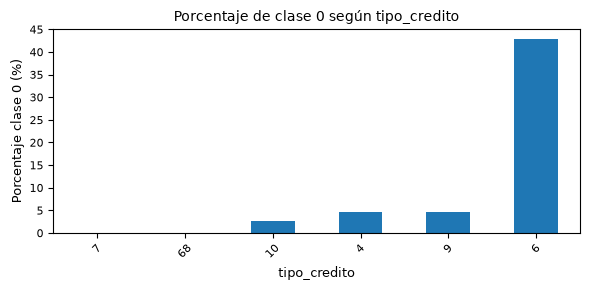

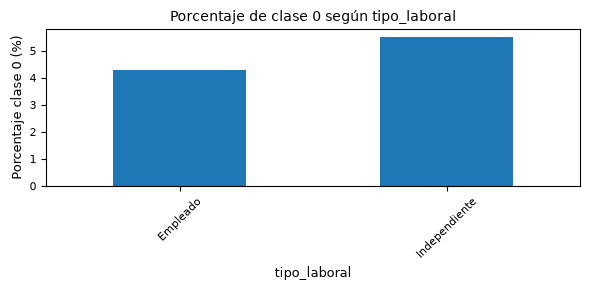

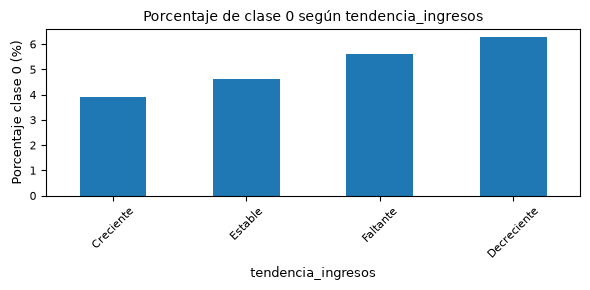

In [85]:
for variable in variables_categoricas_predictoras:
    graficar_porcentaje_clase_0(
        df_limpio,
        variable
    )

#### Relación temporal con `Pago_atiempo`

El análisis univariado mostró cambios importantes en el volumen mensual de préstamos a lo largo del período analizado.

En esta etapa se evalúa si también existen variaciones temporales en la proporción de registros pertenecientes a cada clase de `Pago_atiempo`.

Debido al fuerte desbalance de la variable objetivo, se analiza principalmente el porcentaje mensual correspondiente a la clase 0 y no únicamente su cantidad absoluta.

In [86]:
mes_prestamo = df_limpio["fecha_prestamo"].dt.to_period("M")

In [87]:
# Tabla cruazada

tabla_mensual_objetivo = pd.crosstab(
    mes_prestamo,
    df_limpio["Pago_atiempo"]
)

tabla_mensual_objetivo["total"] = (
    tabla_mensual_objetivo.sum(axis=1)
)

tabla_mensual_objetivo["porcentaje_pago_0"] = (
    tabla_mensual_objetivo[0]
    / tabla_mensual_objetivo["total"]
    * 100
).round(2)

tabla_mensual_objetivo["porcentaje_pago_1"] = (
    tabla_mensual_objetivo[1]
    / tabla_mensual_objetivo["total"]
    * 100
).round(2)

tabla_mensual_objetivo

Pago_atiempo,0,1,total,porcentaje_pago_0,porcentaje_pago_1
fecha_prestamo,,,,,
2024-11,13,173,186,6.99,93.01
2024-12,74,1142,1216,6.09,93.91
2025-01,86,1831,1917,4.49,95.51
2025-02,64,1030,1094,5.85,94.15
2025-03,57,1058,1115,5.11,94.89
2025-04,69,1033,1102,6.26,93.74
2025-05,47,1036,1083,4.34,95.66
2025-06,25,640,665,3.76,96.24
2025-07,20,624,644,3.11,96.89


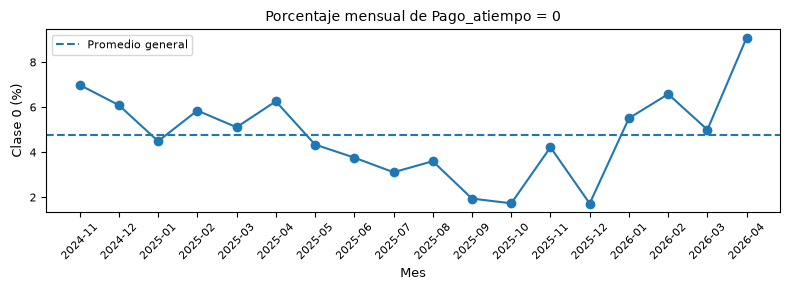

In [88]:
plt.figure(figsize=(8, 3))

plt.plot(
    tabla_mensual_objetivo.index.astype(str),
    tabla_mensual_objetivo["porcentaje_pago_0"],
    marker="o"
)

plt.axhline(
    y=(df_limpio["Pago_atiempo"] == 0).mean() * 100,
    linestyle="--",
    label="Promedio general"
)

plt.title(
    "Porcentaje mensual de Pago_atiempo = 0",
    fontsize=10
)
plt.xlabel("Mes", fontsize=9)
plt.ylabel("Clase 0 (%)", fontsize=9)
plt.xticks(rotation=45)
plt.tick_params(labelsize=8)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [89]:
# Día de semana vs Pago_atiempo

dia_semana = (
    df_limpio["fecha_prestamo"]
    .dt.day_name()
)

In [90]:
orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

tabla_dia_objetivo = pd.crosstab(
    dia_semana,
    df_limpio["Pago_atiempo"]
).reindex(orden_dias)

tabla_dia_objetivo["total"] = (
    tabla_dia_objetivo.sum(axis=1)
)

tabla_dia_objetivo["porcentaje_pago_0"] = (
    tabla_dia_objetivo[0]
    / tabla_dia_objetivo["total"]
    * 100
).round(2)

tabla_dia_objetivo["porcentaje_pago_1"] = (
    tabla_dia_objetivo[1]
    / tabla_dia_objetivo["total"]
    * 100
).round(2)

tabla_dia_objetivo

Pago_atiempo,0,1,total,porcentaje_pago_0,porcentaje_pago_1
fecha_prestamo,,,,,
Monday,65,1242,1307,4.97,95.03
Tuesday,47,1365,1412,3.33,96.67
Wednesday,44,1210,1254,3.51,96.49
Thursday,91,1808,1899,4.79,95.21
Friday,70,1719,1789,3.91,96.09
Saturday,101,1520,1621,6.23,93.77
Sunday,93,1388,1481,6.28,93.72


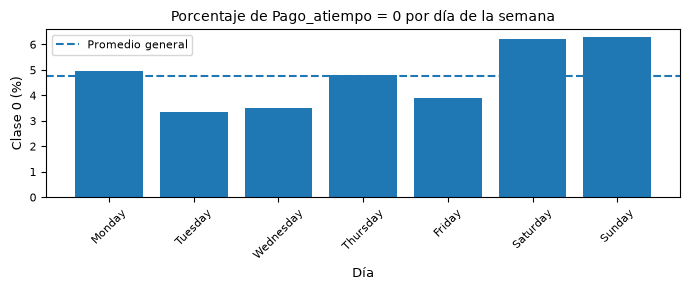

In [91]:
plt.figure(figsize=(7, 3))

plt.bar(
    tabla_dia_objetivo.index,
    tabla_dia_objetivo["porcentaje_pago_0"]
)

plt.axhline(
    y=(df_limpio["Pago_atiempo"] == 0).mean() * 100,
    linestyle="--",
    label="Promedio general"
)

plt.title(
    "Porcentaje de Pago_atiempo = 0 por día de la semana",
    fontsize=10
)
plt.xlabel("Día", fontsize=9)
plt.ylabel("Clase 0 (%)", fontsize=9)
plt.xticks(rotation=45)
plt.tick_params(labelsize=8)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

##### Conclusiones del análisis temporal respecto de la variable objetivo

La proporción de `Pago_atiempo = 0` presenta variaciones a lo largo del período analizado. Durante varios meses iniciales se observan porcentajes superiores al promedio general del 4,75 %, mientras que entre mediados y finales de 2025 se registran porcentajes considerablemente menores.

Durante 2026 vuelven a aparecer tasas superiores al promedio. Sin embargo, estos resultados deben interpretarse con cautela debido a la reducción progresiva del número de observaciones mensuales. Por ejemplo, abril de 2026 presenta una tasa de clase 0 del 9,09 %, pero corresponde únicamente a 1 caso sobre 11 registros.

El análisis por día de la semana muestra diferencias más estables debido al mayor número de observaciones disponible en cada categoría. Los sábados y domingos presentan las mayores proporciones de clase 0, con 6,23 % y 6,28 % respectivamente, mientras que martes y miércoles presentan las menores, con 3,33 % y 3,51 %.

Estos patrones indican que la dimensión temporal podría contener información útil para etapas posteriores. No obstante, las diferencias observadas representan asociaciones y no permiten establecer relaciones causales.

#### Conclusiones generales del análisis bivariado

El análisis bivariado permitió estudiar cómo se relacionan distintas características del dataset con `Pago_atiempo`, considerada la variable objetivo.

Entre las variables numéricas, `puntaje` presenta la separación más marcada entre las clases. La mediana es aproximadamente 25,42 para `Pago_atiempo = 0` y 95,23 para `Pago_atiempo = 1`. `puntaje_datacredito`, `edad_cliente` y `huella_consulta` también presentan diferencias consistentes, aunque con mayor solapamiento entre sus distribuciones.

Las variables monetarias muestran diferencias entre clases, pero también presentan fuerte dispersión y valores extremos. Por este motivo, las medianas y las distribuciones completas resultaron más informativas que las medias consideradas de manera aislada.

El análisis específico de `saldo_mora` permitió identificar un patrón que no era visible mediante la mediana: el 4,00 % de los registros válidos de la clase 0 presenta mora positiva, frente al 0,35 % de la clase 1.

Entre las variables categóricas, los códigos principales de `tipo_credito` presentan comportamientos similares. `tipo_laboral` muestra una proporción algo mayor de clase 0 entre clientes independientes. `tendencia_ingresos` presenta un patrón más claro: la categoría `Creciente` registra la menor proporción de clase 0, mientras que `Decreciente` presenta la mayor. Los valores faltantes también muestran un comportamiento diferente, por lo que la ausencia de información podría contener señal relevante.

Finalmente, se identificaron variaciones temporales en la proporción de la clase 0. Los resultados mensuales deben interpretarse junto con el número de observaciones de cada período, mientras que el análisis por día de la semana muestra una mayor proporción de clase 0 durante sábados y domingos.

En todos los casos, las diferencias observadas se interpretan como asociaciones presentes en el dataset y no como evidencia de relaciones causales.

### Análisis Multivariado

El análisis multivariado busca estudiar relaciones simultáneas entre distintas características del dataset.

A diferencia del análisis bivariado, que se centró principalmente en comparar cada variable con `Pago_atiempo`, en esta etapa se analizarán también las relaciones existentes entre las variables predictoras.

El objetivo es identificar asociaciones relevantes, posibles redundancias entre características, grupos de variables relacionadas y patrones que puedan resultar útiles para etapas posteriores de feature engineering, validación de datos y modelado.

Las relaciones observadas se interpretarán como asociaciones estadísticas y no como relaciones causales.

#### Matriz de correlación

In [92]:
variables_correlacion = variables_numericas + ["Pago_atiempo"]

df_correlacion = df_limpio[variables_correlacion].copy()

print("Dimensiones utilizadas para la matriz:")
print(df_correlacion.shape)

Dimensiones utilizadas para la matriz:
(10763, 19)


In [93]:
# Calcular correlación de Spearman

matriz_spearman = (
    df_correlacion
    .corr(method="spearman")
)

matriz_spearman.round(2)

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
capital_prestado,1.00,0.32,-0.02,0.31,0.19,0.75,-0.01,0.09,0.06,0.03,0.01,0.15,0.14,0.00,0.14,-0.03,-0.13,0.11,-0.04
plazo_meses,0.32,1.00,-0.08,-0.13,-0.17,-0.31,0.01,-0.03,-0.00,0.03,0.01,-0.04,-0.04,-0.00,-0.00,0.03,-0.02,0.08,-0.02
edad_cliente,-0.02,-0.08,1.00,0.11,0.10,0.04,0.06,0.41,0.10,-0.19,0.01,0.09,0.09,0.01,0.12,0.04,0.00,-0.04,0.06
salario_cliente,0.31,-0.13,0.11,1.00,0.71,0.39,-0.02,0.10,0.30,0.12,0.02,0.45,0.43,0.00,0.35,-0.02,-0.02,0.21,-0.00
total_otros_prestamos,0.19,-0.17,0.10,0.71,1.00,0.30,-0.01,0.07,0.29,0.09,0.01,0.44,0.44,-0.01,0.32,0.01,0.00,0.14,0.03
cuota_pactada,0.75,-0.31,0.04,0.39,0.30,1.00,-0.01,0.11,0.07,0.01,0.00,0.18,0.16,0.00,0.13,-0.05,-0.11,0.05,-0.01
puntaje,-0.01,0.01,0.06,-0.02,-0.01,-0.01,1.00,0.12,-0.00,-0.06,-0.09,-0.02,-0.03,0.01,0.02,0.02,-0.04,0.08,0.64
puntaje_datacredito,0.09,-0.03,0.41,0.10,0.07,0.11,0.12,1.00,-0.04,-0.22,-0.10,0.06,0.05,-0.00,0.17,0.00,-0.26,0.13,0.09
cant_creditosvigentes,0.06,-0.00,0.10,0.30,0.29,0.07,-0.00,-0.04,1.00,0.33,0.03,0.61,0.58,-0.00,0.76,0.16,0.48,0.12,0.02
huella_consulta,0.03,0.03,-0.19,0.12,0.09,0.01,-0.06,-0.22,0.33,1.00,-0.03,0.23,0.21,-0.03,0.28,0.03,0.18,0.03,-0.07


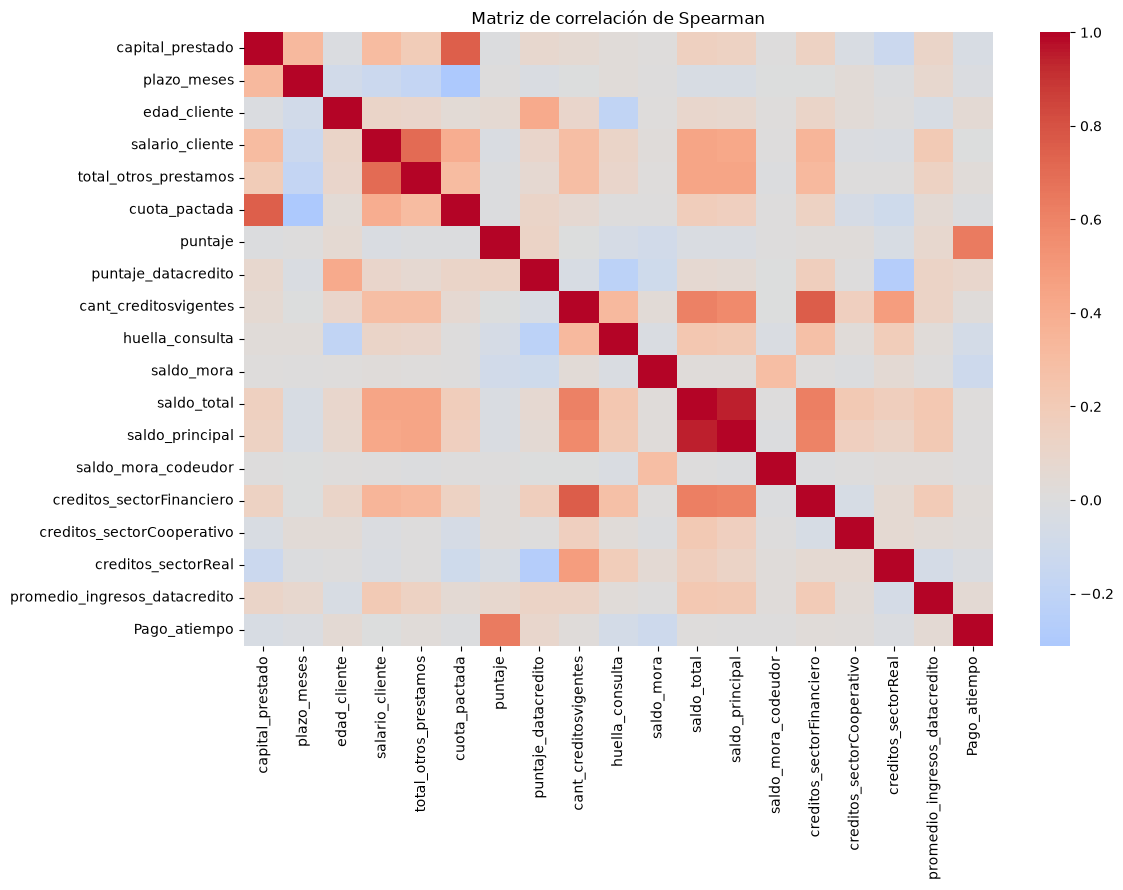

In [94]:
# Heatmap

plt.figure(figsize=(12, 9))

sns.heatmap(
    matriz_spearman,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title(
    "Matriz de correlación de Spearman",
    fontsize=12
)

plt.tight_layout()
plt.show()

#### Correlaciones con `Pago_atiempo`

In [95]:
correlacion_objetivo = (
    matriz_spearman["Pago_atiempo"]
    .drop("Pago_atiempo")
    .sort_values()
)

correlacion_objetivo.round(3)

saldo_mora                      -0.108
huella_consulta                 -0.073
capital_prestado                -0.042
creditos_sectorReal             -0.018
plazo_meses                     -0.016
cuota_pactada                   -0.015
salario_cliente                 -0.005
saldo_mora_codeudor              0.004
saldo_principal                  0.009
saldo_total                      0.015
cant_creditosvigentes            0.016
creditos_sectorCooperativo       0.024
total_otros_prestamos            0.026
creditos_sectorFinanciero        0.030
promedio_ingresos_datacredito    0.051
edad_cliente                     0.056
puntaje_datacredito              0.091
puntaje                          0.639
Name: Pago_atiempo, dtype: float64

#### Correlaciones más altas

In [96]:
matriz_predictoras = matriz_spearman.drop(
    index="Pago_atiempo",
    columns="Pago_atiempo"
)

correlaciones_pares = (
    matriz_predictoras
    .where(
        np.triu(
            np.ones(matriz_predictoras.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

correlaciones_pares.columns = [
    "variable_1",
    "variable_2",
    "correlacion"
]

correlaciones_pares["correlacion_absoluta"] = (
    correlaciones_pares["correlacion"].abs()
)

correlaciones_pares = (
    correlaciones_pares
    .sort_values(
        "correlacion_absoluta",
        ascending=False
    )
)

correlaciones_pares.head(15)

,variable_1,variable_2,correlacion,correlacion_absoluta
210,saldo_total,saldo_principal,0.946326,0.946326
158,cant_creditosvigentes,creditos_sectorFinanciero,0.755234,0.755234
5,capital_prestado,cuota_pactada,0.750691,0.750691
58,salario_cliente,total_otros_prestamos,0.705843,0.705843
212,saldo_total,creditos_sectorFinanciero,0.621450,0.621450
155,cant_creditosvigentes,saldo_total,0.613569,0.613569
230,saldo_principal,creditos_sectorFinanciero,0.604524,0.604524
156,cant_creditosvigentes,saldo_principal,0.578879,0.578879
160,cant_creditosvigentes,creditos_sectorReal,0.478124,0.478124
65,salario_cliente,saldo_total,0.445360,0.445360


##### Interpretación de la matriz de correlación

La matriz de correlación de Spearman permitió identificar asociaciones entre las variables numéricas sin asumir relaciones estrictamente lineales y reduciendo la sensibilidad frente a las distribuciones asimétricas y los valores extremos observados previamente.

Respecto de la variable objetivo, `puntaje` presenta la asociación más elevada, con una correlación de aproximadamente 0,639 con `Pago_atiempo`. Este resultado es consistente con las diferencias observadas durante el análisis bivariado. Las demás variables presentan correlaciones considerablemente menores con el objetivo.

Una correlación baja no implica necesariamente ausencia de información predictiva. Por ejemplo, `saldo_mora` presenta una correlación de aproximadamente -0,108 con `Pago_atiempo`, aunque el análisis bivariado mostró que la presencia de mora positiva es proporcionalmente más frecuente dentro de la clase 0.

Entre las variables predictoras se destaca la elevada correlación entre `saldo_total` y `saldo_principal` (aproximadamente 0,946), lo que indica una posible redundancia de información y deberá considerarse posteriormente al evaluar multicolinealidad.

También se observan asociaciones importantes entre `cant_creditosvigentes` y `creditos_sectorFinanciero` (0,755), `capital_prestado` y `cuota_pactada` (0,751), y `salario_cliente` y `total_otros_prestamos` (0,706).

Además, diferentes variables relacionadas con el nivel de endeudamiento presentan correlaciones entre sí, sugiriendo la existencia de un grupo de características que describen dimensiones relacionadas del comportamiento crediticio.

Las correlaciones observadas representan asociaciones estadísticas y no relaciones causales.

#### Visualización de relaciones

In [97]:
relaciones_seleccionadas = [
    ("saldo_total", "saldo_principal"),
    ("capital_prestado", "cuota_pactada"),
    ("salario_cliente", "total_otros_prestamos"),
    ("edad_cliente", "puntaje_datacredito")
]

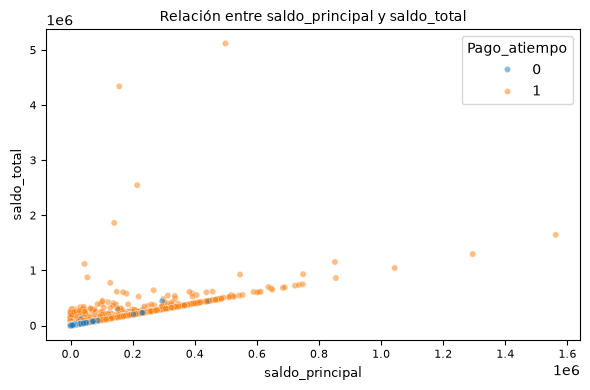

In [98]:
# Relación más fuerte - Saldo_total vs saldo_principal

plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=df_limpio,
    x="saldo_principal",
    y="saldo_total",
    hue="Pago_atiempo",
    alpha=0.5,
    s=20
)

plt.title(
    "Relación entre saldo_principal y saldo_total",
    fontsize=10
)
plt.xlabel("saldo_principal", fontsize=9)
plt.ylabel("saldo_total", fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

La relación visual confirma muy claramente la correlación de Spearman de 0,946.
La mayor parte de las observaciones forma una trayectoria prácticamente lineal: cuando aumenta saldo_principal, también tiende a aumentar saldo_total. Hay algunos registros en los que saldo_total es mucho mayor que saldo_principal, lo cual explica que la relación no sea perfectamente 1:1.


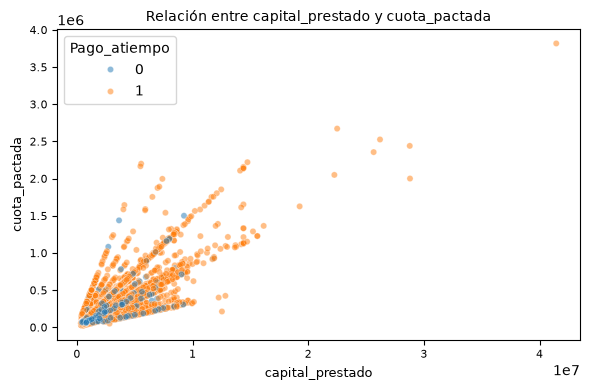

In [99]:
# capital_prestado vs cuota_pactada

plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=df_limpio,
    x="capital_prestado",
    y="cuota_pactada",
    hue="Pago_atiempo",
    alpha=0.5,
    s=20
)

plt.title(
    "Relación entre capital_prestado y cuota_pactada",
    fontsize=10
)
plt.xlabel("capital_prestado", fontsize=9)
plt.ylabel("cuota_pactada", fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

Se ve muy bien la correlación positiva de aproximadamente 0,751.
Pero hay algo muy interesante, los puntos no forman una única recta, sino varias especies de bandas o trayectorias. Esto tiene bastante sentido porque una cuota no depende únicamente del capital.

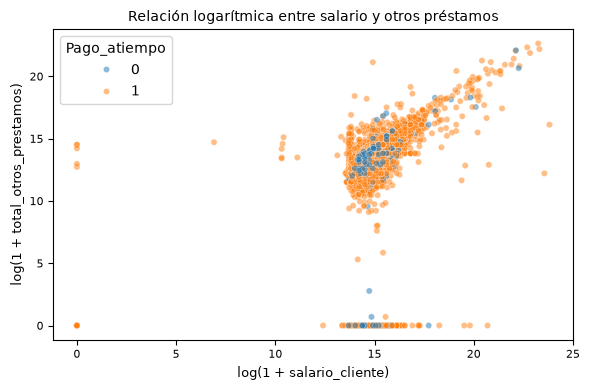

In [100]:
# Salario vs otros préstamos

plt.figure(figsize=(6, 4))

sns.scatterplot(
    x=np.log1p(df_limpio["salario_cliente"]),
    y=np.log1p(df_limpio["total_otros_prestamos"]),
    hue=df_limpio["Pago_atiempo"],
    alpha=0.5,
    s=20
)

plt.title(
    "Relación logarítmica entre salario y otros préstamos",
    fontsize=10
)
plt.xlabel("log(1 + salario_cliente)", fontsize=9)
plt.ylabel("log(1 + total_otros_prestamos)", fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

Se puede ver una tendencia positiva bastante clara dentro de la nube principal: clientes con mayores salarios tienden también a presentar mayores montos de otros préstamos. Pero el gráfico también muestra una franja horizontal que corresponde a clientes sin otros préstamos.  
A su vez, se puede observar registros que forman una pequeña estructura separada, estos son los clientes con salario cero.

Esto muestra que la relación positiva existe dentro de una gran parte de los datos, pero el dataset también tiene subgrupos estructurales que no siguen el mismo patrón.

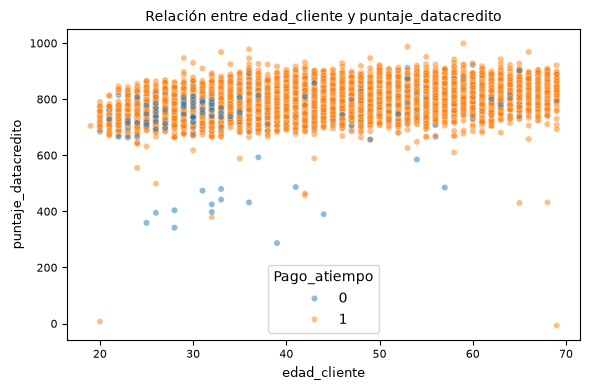

In [101]:
# Edad vs puntaje datacrédito

plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=df_limpio,
    x="edad_cliente",
    y="puntaje_datacredito",
    hue="Pago_atiempo",
    alpha=0.5,
    s=20
)

plt.title(
    "Relación entre edad_cliente y puntaje_datacredito",
    fontsize=10
)
plt.xlabel("edad_cliente", fontsize=9)
plt.ylabel("puntaje_datacredito", fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

El gráfico permite ver la correlación moderada de aproximadamente 0,413, aunque no aparece una relación tan nítida como en los casos anteriores.
La mayoría de `puntaje_datacredito`se concentra entre 700 y 900.
En términos generales, el puntje parece desplazarse hacia valores mayores conforme aumenta la edad, pero existe muchísimo solapamiento.

#### Posible redundancia y multicolinealidad

Las correlaciones elevadas entre variables predictoras pueden indicar que algunas características contienen información parcialmente redundante.

Esta situación puede ser especialmente relevante para modelos lineales, donde una alta multicolinealidad puede dificultar la interpretación de los coeficientes.

En esta etapa no se eliminan variables. Se identifican las relaciones que deberán considerarse posteriormente durante el preprocesamiento y modelado.

In [102]:
correlaciones_altas = (
    correlaciones_pares[
        correlaciones_pares["correlacion_absoluta"] >= 0.70
    ]
    .copy()
)

correlaciones_altas.round(3)

,variable_1,variable_2,correlacion,correlacion_absoluta
210,saldo_total,saldo_principal,0.946,0.946
158,cant_creditosvigentes,creditos_sectorFinanciero,0.755,0.755
5,capital_prestado,cuota_pactada,0.751,0.751
58,salario_cliente,total_otros_prestamos,0.706,0.706


##### Revisión por posible relacion estructural entre saldos

In [103]:

mascara_saldo = (
    df_limpio["saldo_total"].notna()
    & df_limpio["saldo_principal"].notna()
    & (df_limpio["saldo_total"] > 0)
)

ratio_principal_total = (
    df_limpio.loc[mascara_saldo, "saldo_principal"]
    / df_limpio.loc[mascara_saldo, "saldo_total"]
)

ratio_principal_total.describe().round(3)

count    9818.000
mean        0.925
std         0.215
min         0.000
25%         1.000
50%         1.000
75%         1.000
max         1.000
dtype: float64

In [104]:
print(
    "Porcentaje de registros donde saldo_principal "
    "representa al menos el 80% de saldo_total:"
)

print(
    round(
        (ratio_principal_total >= 0.80).mean() * 100,
        2
    ),
    "%"
)

Porcentaje de registros donde saldo_principal representa al menos el 80% de saldo_total:
88.67 %


Relación entre `saldo_principal` y `saldo_total`

La elevada correlación entre `saldo_principal` y `saldo_total` fue analizada con mayor detalle.

Entre los 9.818 registros con información disponible y `saldo_total > 0`, el ratio `saldo_principal / saldo_total` presenta una mediana de 1,00. Además, el 88,67 % de las observaciones presenta un ratio igual o superior a 0,80.

El máximo observado del ratio es 1,00, por lo que no se identificaron casos donde `saldo_principal` supere a `saldo_total` dentro de los registros analizados.

Estos resultados refuerzan la existencia de una posible relación estructural y redundancia entre ambas características. Como regla candidata de calidad podría considerarse `saldo_principal <= saldo_total`, aunque deberá confirmarse posteriormente con la definición de negocio de ambas variables.

#### Conversión del EDA en decisiones

###### Posibles reglas para validación de datos
A partir de las anomalías y patrones identificados durante el EDA se pueden proponer reglas de validación para futuras etapas del pipeline.
Estas reglas se consideran candidatas y deberán ser contrastadas con las definiciones de negocio antes de utilizarse como restricciones definitivas.

| Variable / grupo | Regla candidata | Evidencia del EDA |
|---|---|---|
| `Pago_atiempo` | Valores permitidos: 0 o 1 | Solo se observaron ambas clases |
| `edad_cliente` | Valores superiores a 100 requieren validación | Se detectaron 150 registros entre 121 y 123 años, concentrados principalmente en 122 |
| `tipo_laboral` | Categorías esperadas: `Empleado`, `Independiente` | Fueron las únicas categorías observadas |
| `tendencia_ingresos` | Categorías esperadas: `Creciente`, `Decreciente`, `Estable` o valor faltante | Se detectaron 58 valores numéricos almacenados como texto y fueron tratados como inválidos |
| `saldo_principal` / `saldo_total` | Evaluar que `saldo_principal <= saldo_total` | En 9.818 registros comparables el ratio nunca superó 1 |
| Variables de conteo | No deberían presentar valores negativos sin justificación | Los valores observados fueron iguales o superiores a cero |
| Variables monetarias de saldo/capital/cuota | Valores negativos requieren revisión | No se observaron valores negativos en estas variables |
| `fecha_prestamo` | Debe poder convertirse correctamente a fecha/hora | Los 10.763 registros pudieron convertirse correctamente |

##### Validación multivariada adicional

In [105]:
creditos_sector_total = (
    df_limpio["creditos_sectorFinanciero"]
    + df_limpio["creditos_sectorCooperativo"]
    + df_limpio["creditos_sectorReal"]
)

comparacion_creditos = pd.DataFrame({
    "cant_creditosvigentes": df_limpio["cant_creditosvigentes"],
    "suma_creditos_sector": creditos_sector_total
})

comparacion_creditos["diferencia"] = (
    comparacion_creditos["cant_creditosvigentes"]
    - comparacion_creditos["suma_creditos_sector"]
)

comparacion_creditos.describe().round(2)

,cant_creditosvigentes,suma_creditos_sector,diferencia
count,10763.00,10763.00,10763.00
mean,5.73,4.35,1.37
std,3.98,3.49,1.31
min,0.00,0.00,-2.00
25%,3.00,2.00,0.00
50%,5.00,4.00,1.00
75%,8.00,6.00,2.00
max,62.00,60.00,12.00


In [106]:
print(
    "Registros donde cant_creditosvigentes "
    "coincide exactamente con la suma por sectores:"
)

coinciden_creditos = (
    comparacion_creditos["diferencia"] == 0
)

print(
    coinciden_creditos.sum(),
    "de",
    len(comparacion_creditos)
)

print(
    f"Porcentaje: {coinciden_creditos.mean() * 100:.2f}%"
)


Registros donde cant_creditosvigentes coincide exactamente con la suma por sectores:
3117 de 10763
Porcentaje: 28.96%


In [107]:
comparacion_creditos["diferencia"].value_counts().sort_index()

diferencia
-2        2
-1        2
 0     3117
 1     3460
 2     2368
 3     1100
 4      435
 5      180
 6       60
 7       23
 8        8
 9        6
 10       1
 12       1
Name: count, dtype: int64

Se evaluó si `cant_creditosvigentes` correspondía exactamente a la suma de los créditos registrados en los sectores financiero, cooperativo y real.
La igualdad se cumple en 3.117 de los 10.763 registros, equivalente al 28,96 % del dataset. La diferencia entre `cant_creditosvigentes` y la suma de los tres sectores presenta una mediana de 1 y una media de 1,37.
En la mayoría de los registros donde existen diferencias, `cant_creditosvigentes` es superior a la suma sectorial. También se identificaron cuatro observaciones donde la suma por sectores supera al total de créditos vigentes.
Por lo tanto, aunque estas variables se encuentran relacionadas, no existe evidencia suficiente para interpretar los tres sectores como componentes exhaustivos de `cant_creditosvigentes`. No se aplican modificaciones y las diferencias quedan documentadas para una eventual validación con las definiciones de negocio.

##### Posibles transformaciones

El EDA permitió identificar variables cuya distribución o estructura podría requerir transformaciones antes del entrenamiento de determinados modelos.
Las transformaciones propuestas en esta sección son candidatas y no se aplican todavía al dataset. Su utilización deberá definirse posteriormente según el algoritmo seleccionado y el pipeline de preprocesamiento.

###### Indicadores de información faltante

El análisis mostró que la ausencia de información podría contener señal relevante en algunas características. Por ejemplo, los registros con `tendencia_ingresos` faltante presentaron una proporción de clase 0 diferente del promedio general.
Por este motivo, en etapas posteriores puede evaluarse la creación de indicadores binarios que identifiquen la ausencia de determinadas variables antes de realizar su imputación.

###### Variables derivadas de la fecha

A partir de `fecha_prestamo` podrían generarse posteriormente características temporales como:

- año del préstamo;
- mes;
- día de la semana;
- indicador de fin de semana.

El análisis bivariado mostró diferencias en la proporción de `Pago_atiempo = 0` según el período y el día de la semana, por lo que estas características podrían aportar información al modelo.

###### Ratios financieros candidatos

El análisis multivariado también permite proponer atributos derivados que combinen información existente.

Entre los candidatos se encuentran:

- `cuota_pactada / capital_prestado`: relación entre la cuota y el capital otorgado.
- `total_otros_prestamos / salario_cliente`: posible aproximación al nivel de endeudamiento respecto de los ingresos.
- `saldo_principal / saldo_total`: proporción del saldo total representada por el principal.

Estos atributos no se generan todavía. Antes de incorporarlos será necesario definir el tratamiento adecuado de denominadores iguales a cero y validar su interpretación desde el punto de vista de negocio.

###### Revisión futura de posibles variables con fuga de información

Antes del entrenamiento será necesario confirmar qué información se encuentra realmente disponible en el momento en que debe realizarse la predicción.

Variables como `saldo_mora` y especialmente `puntaje`, que presentan asociaciones importantes con `Pago_atiempo`, deberán ser revisadas desde el punto de vista temporal y de negocio.

Si alguna característica fuese calculada utilizando información posterior al momento de la predicción, su utilización generaría fuga de información (`data leakage`) y debería excluirse del conjunto de predictores.

En esta etapa no se elimina ninguna variable, ya que no se dispone todavía de evidencia suficiente para confirmar la existencia de leakage.

#### Conclusiones generales del análisis multivariado

El análisis multivariado permitió profundizar las relaciones existentes entre las características del dataset, identificar posibles redundancias y establecer lineamientos para etapas posteriores de preprocesamiento, feature engineering y modelado.

La matriz de correlación de Spearman mostró que `puntaje` es la variable numérica con mayor asociación respecto de `Pago_atiempo`, con un coeficiente aproximado de 0,639. Este resultado es consistente con el análisis bivariado, donde también se observó una marcada diferencia en la distribución de esta variable entre las clases. Las demás características presentan asociaciones individuales considerablemente menores con la variable objetivo.

Entre las variables predictoras se identificó una relación especialmente elevada entre `saldo_total` y `saldo_principal`, con una correlación de aproximadamente 0,946. El análisis posterior confirmó que, entre los registros comparables, la mediana del ratio `saldo_principal / saldo_total` es igual a 1 y que en el 88,67 % de los casos `saldo_principal` representa al menos el 80 % de `saldo_total`. Estos resultados indican una posible redundancia que deberá considerarse durante el modelado, especialmente en algoritmos sensibles a la multicolinealidad.

También se identificaron asociaciones elevadas entre `cant_creditosvigentes` y `creditos_sectorFinanciero` (aproximadamente 0,755), `capital_prestado` y `cuota_pactada` (0,751), y `salario_cliente` y `total_otros_prestamos` (0,706). Las visualizaciones seleccionadas permitieron confirmar que estas relaciones presentan estructuras reconocibles, aunque no necesariamente implican que una variable pueda reemplazar directamente a la otra.

Se evaluó además si `cant_creditosvigentes` correspondía a la suma de los créditos registrados en los sectores financiero, cooperativo y real. La igualdad se observó solamente en el 28,96 % de los registros, por lo que no existe evidencia suficiente para considerar que las variables sectoriales representen componentes exhaustivos del total de créditos vigentes.

A partir del EDA se identificaron posibles reglas de validación de datos, entre ellas la revisión de edades superiores a 100 años, la validación de las categorías esperadas en variables categóricas y la relación candidata `saldo_principal <= saldo_total`. Estas reglas deberán confirmarse posteriormente con las definiciones de negocio antes de convertirse en restricciones definitivas del pipeline.

También se propusieron posibles transformaciones para etapas posteriores. Las variables monetarias con fuerte asimetría podrían evaluarse mediante transformaciones logarítmicas, mientras que el escalado deberá definirse según el algoritmo seleccionado. Los valores faltantes requerirán estrategias de imputación dentro del pipeline y, en algunos casos, podría resultar útil conservar adicionalmente un indicador de ausencia de información.

La variable `fecha_prestamo` ofrece la posibilidad de generar atributos temporales como año, mes, día de la semana o indicador de fin de semana. También se identificaron posibles ratios financieros, como la relación entre cuota y capital prestado, entre otros préstamos e ingresos, y entre saldo principal y saldo total. Estas características se consideran candidatas y no fueron incorporadas todavía al dataset.

Finalmente, antes del entrenamiento será necesario revisar el momento de disponibilidad de determinadas variables, especialmente aquellas con una asociación elevada con la variable objetivo. Esto permitirá prevenir posibles situaciones de fuga de información (`data leakage`) y garantizar que el modelo utilice únicamente información disponible al momento de realizar una predicción.

En esta etapa no se eliminaron variables por correlación, no se aplicaron transformaciones definitivas y no se generaron nuevas características. El objetivo fue identificar y documentar relaciones, riesgos y oportunidades que sirvan de fundamento para las siguientes etapas del proyecto.